# 异星求生：LLM Agent 多维能力评测 — 数据分析

对应 REPORT.md 中的图表占位，逐节生成可视化和统计检验。

In [1]:
import json, os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from collections import Counter, defaultdict
from pathlib import Path

# seaborn 样式（必须在字体设置之前，否则会重置字体）
sns.set_style('whitegrid')

# 中文字体
import matplotlib.font_manager as _fm
_font_path = '/Library/Fonts/Arial Unicode.ttf'
_fm.fontManager.addfont(_font_path)
plt.rcParams['font.family'] = _fm.FontProperties(fname=_font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['figure.facecolor'] = 'white'

# 路径
BASE = Path('/Users/zhihu/code/cli_sandbox')
RESULTS = BASE / 'eval_results' / 'seed_42'
FIGURES = BASE / 'figures'
FIGURES.mkdir(exist_ok=True)

# 加载 CSV
df = pd.read_csv(RESULTS / 'all_sessions.csv')
print(f'Loaded {len(df)} sessions, {df["player_tag"].nunique()} configs')


Loaded 229 sessions, 23 configs


In [2]:
# ── 解析 player_tag → 模型名 + 思维模式 ──

TAG_MAP = {
    'claude_opus_off':    ('Claude Opus 4.6',   'off'),
    'claude_opus_on':     ('Claude Opus 4.6',   'on'),
    'claude_sonnet_off':  ('Claude Sonnet 4.5', 'off'),
    'claude_sonnet_on':   ('Claude Sonnet 4.5', 'on'),
    'gpt52_off':          ('GPT-5.2',           'off'),
    'gpt52_on':           ('GPT-5.2',           'on'),
    'gpt52_chat_off':     ('GPT-5.2-chat',      'off'),
    'gpt52_chat_on':      ('GPT-5.2-chat',      'on'),
    'gemini_3_pro_off':   ('Gemini 3-Pro',      'off'),
    'gemini_3_pro_high':  ('Gemini 3-Pro',      'on'),
    'gemini_3_flash_off': ('Gemini 3-Flash',    'off'),
    'gemini_3_flash_high':('Gemini 3-Flash',    'on'),
    'deepseek_v32_off':   ('DeepSeek V3.2',     'off'),
    'deepseek_v32_on':    ('DeepSeek V3.2',     'on'),
    'kimi_25_off':        ('Kimi K2.5',         'off'),
    'kimi_25_on':         ('Kimi K2.5',         'on'),
    'doubao-v18_off':     ('Doubao Seed 1.8',   'off'),
    'doubao-v18_on':      ('Doubao Seed 1.8',   'on'),
    'glm_5_off':          ('GLM-5',             'off'),
    'glm_5_on':           ('GLM-5',             'on'),
    'step_35_flash_off':  ('Step 3.5 Flash',    'off'),
    'step_35_flash_on':   ('Step 3.5 Flash',    'on'),
    'qwen3_max_off':      ('Qwen3 Max',         'off'),
}

df['model'] = df['player_tag'].map(lambda t: TAG_MAP.get(t, (t, '?'))[0])
df['thinking'] = df['player_tag'].map(lambda t: TAG_MAP.get(t, (t, '?'))[1])
df['label'] = df['model'] + ' ' + df['thinking'].str.upper()

# 模型顺序（按均值排序）
order = df.groupby('label')['hours_survived'].mean().sort_values(ascending=False).index.tolist()
model_order = df.groupby('model')['hours_survived'].mean().sort_values(ascending=False).index.tolist()

# 配色
PALETTE_THINK = {'off': '#4C72B0', 'on': '#DD8452'}

print(f'{len(order)} configs, {len(model_order)} models')
print('Top 5:', order[:5])

23 configs, 12 models
Top 5: ['Claude Opus 4.6 ON', 'GPT-5.2-chat OFF', 'GPT-5.2 OFF', 'Kimi K2.5 ON', 'GPT-5.2-chat ON']


---
## 4.1 整体表现与排名

/var/folders/1v/w400c0x556qgw30t7nnp9l4r0000gn/T/ipykernel_18515/3863563958.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='hours_survived', order=order,
/var/folders/1v/w400c0x556qgw30t7nnp9l4r0000gn/T/ipykernel_18515/3863563958.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)


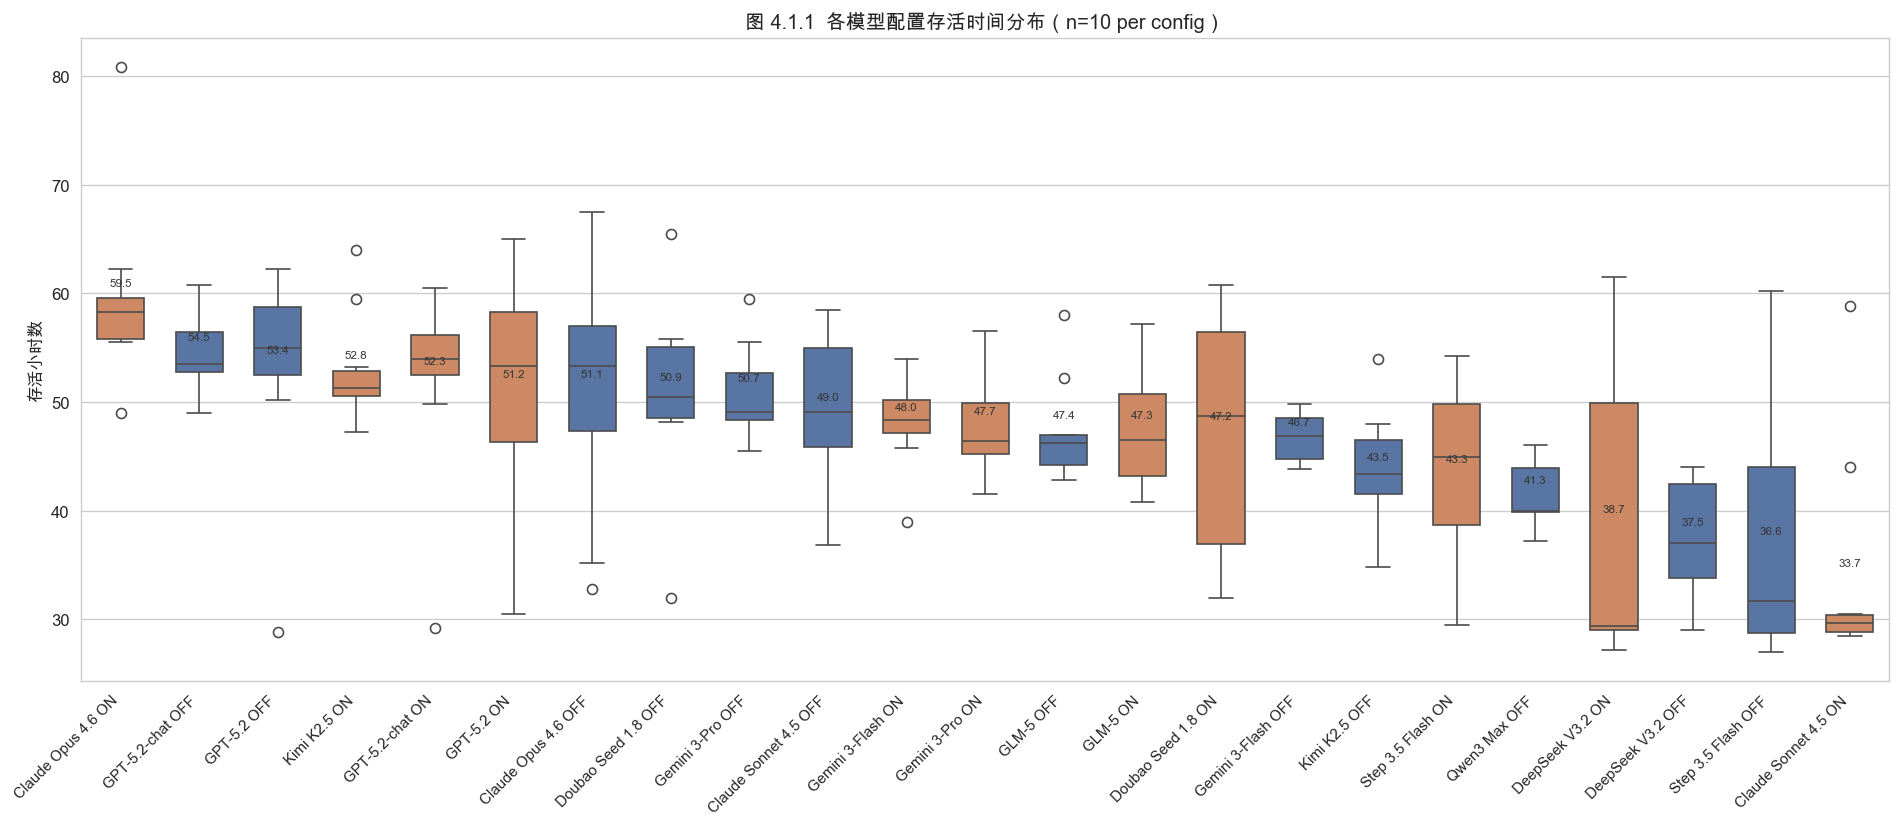

In [3]:
# ── 图 4.1.1：存活时间箱线图（全部配置） ──

fig, ax = plt.subplots(figsize=(16, 7))
sns.boxplot(data=df, x='label', y='hours_survived', order=order,
            palette=[PALETTE_THINK['on'] if 'ON' in l else PALETTE_THINK['off'] for l in order],
            width=0.6, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_ylabel('存活小时数')
ax.set_xlabel('')
ax.set_title('图 4.1.1  各模型配置存活时间分布（n=10 per config）')

# 添加均值标注
means = df.groupby('label')['hours_survived'].mean()
for i, lbl in enumerate(order):
    ax.text(i, means[lbl] + 1, f'{means[lbl]:.1f}', ha='center', va='bottom', fontsize=7, color='#333')

plt.tight_layout()
fig.savefig(FIGURES / 'fig_4_1_1_survival_boxplot.png', bbox_inches='tight')
plt.show()

In [4]:
# ── 表 4.1：完整排名表 ──

rank_df = df.groupby(['label', 'model', 'thinking']).agg(
    hours_mean=('hours_survived', 'mean'),
    hours_std=('hours_survived', 'std'),
    valid_rate_mean=('valid_rate', 'mean'),
    tech_points_mean=('tech_points', 'mean'),
    inventions_mean=('inventions', 'mean'),
    cost_mean=('cost_cny', 'mean'),
    actions_mean=('actions_taken', 'mean'),
    n=('hours_survived', 'count'),
).reset_index().sort_values('hours_mean', ascending=False).reset_index(drop=True)
rank_df.index += 1
rank_df.index.name = '排名'

# 格式化输出
display_cols = ['model', 'thinking', 'hours_mean', 'hours_std', 'valid_rate_mean', 
                'tech_points_mean', 'inventions_mean', 'cost_mean', 'actions_mean', 'n']
print(rank_df[display_cols].to_markdown(floatfmt=('.0f', '', '', '.1f', '.1f', '.2f', '.1f', '.1f', '.2f', '.1f', '.0f')))

|   排名 | model             | thinking   |   hours_mean |   hours_std |   valid_rate_mean |   tech_points_mean |   inventions_mean |   cost_mean |   actions_mean |   n |
|-------:|:------------------|:-----------|-------------:|------------:|------------------:|-------------------:|------------------:|------------:|---------------:|----:|
|      1 | Claude Opus 4.6   | on         |         59.5 |         8.3 |             94.90 |                3.6 |               1.7 |       27.06 |           52.2 |  10 |
|      2 | GPT-5.2-chat      | off        |         54.5 |         3.4 |             89.50 |                2.2 |               0.7 |        4.02 |           46.8 |  10 |
|      3 | GPT-5.2           | off        |         53.4 |         9.4 |             91.50 |                4.1 |               1.8 |        4.75 |           46.0 |  10 |
|      4 | Kimi K2.5         | on         |         52.8 |         5.1 |             94.00 |                2.6 |               0.9 |        2.51 |

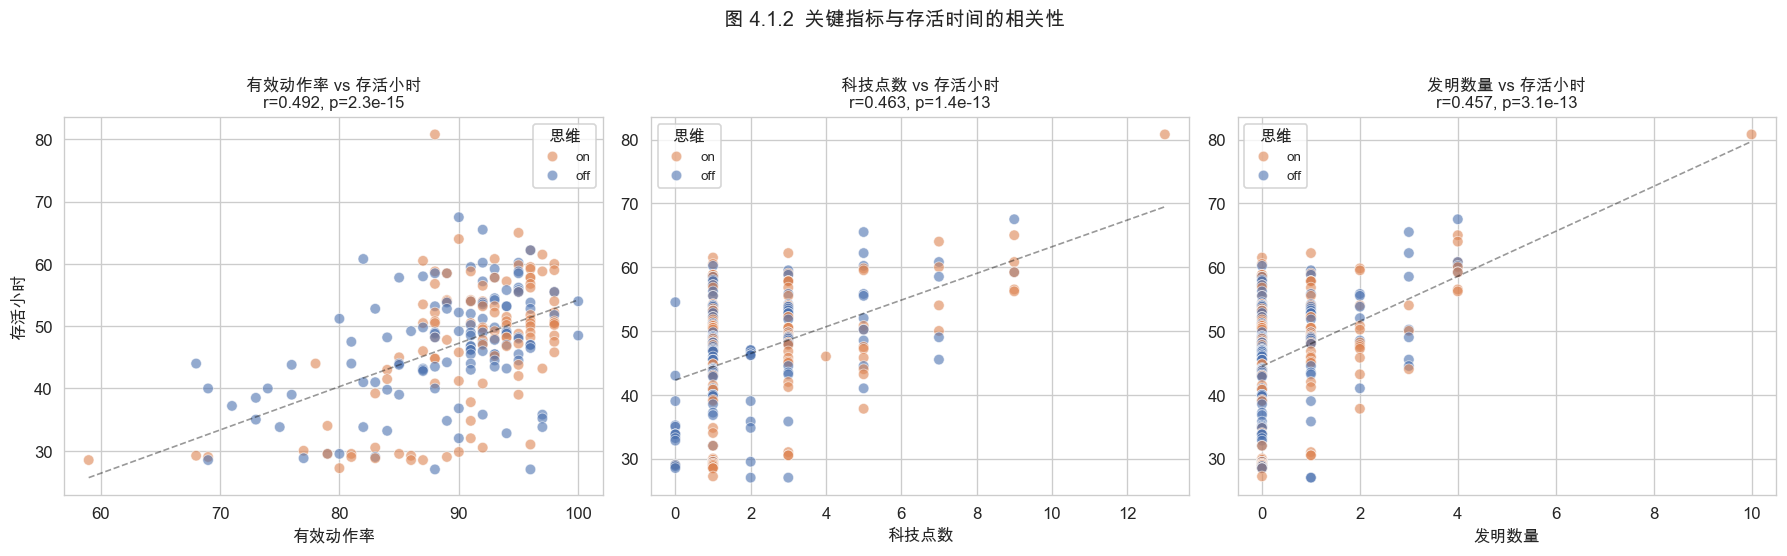

In [5]:
# ── 图 4.1.2：关键指标相关性散点图矩阵 ──

corr_vars = ['hours_survived', 'valid_rate', 'tech_points', 'inventions']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, (xvar, ylabel) in enumerate([
    ('valid_rate', '有效动作率'),
    ('tech_points', '科技点数'),
    ('inventions', '发明数量'),
]):
    ax = axes[i]
    sns.scatterplot(data=df, x=xvar, y='hours_survived', hue='thinking',
                    palette=PALETTE_THINK, alpha=0.6, s=40, ax=ax)
    # 回归线
    r, p = stats.pearsonr(df[xvar].dropna(), df.loc[df[xvar].notna(), 'hours_survived'])
    z = np.polyfit(df[xvar].dropna(), df.loc[df[xvar].notna(), 'hours_survived'], 1)
    xs = np.linspace(df[xvar].min(), df[xvar].max(), 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', alpha=0.4, linewidth=1)
    ax.set_title(f'{ylabel} vs 存活小时\nr={r:.3f}, p={p:.1e}', fontsize=10)
    ax.set_xlabel(ylabel)
    ax.set_ylabel('存活小时' if i == 0 else '')
    ax.legend(title='思维', fontsize=8)

plt.suptitle('图 4.1.2  关键指标与存活时间的相关性', y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES / 'fig_4_1_2_correlation_scatter.png', bbox_inches='tight')
plt.show()

---
## 4.2 思维模式的维度依赖性

In [6]:
# ── 配对模型（同一模型的 off vs on） ──

paired_models = [m for m in model_order if 
                 len(df[(df['model']==m) & (df['thinking']=='off')]) > 0 and
                 len(df[(df['model']==m) & (df['thinking']=='on')]) > 0]
print(f'{len(paired_models)} paired models: {paired_models}')

11 paired models: ['Claude Opus 4.6', 'GPT-5.2-chat', 'GPT-5.2', 'Gemini 3-Pro', 'Doubao Seed 1.8', 'Kimi K2.5', 'Gemini 3-Flash', 'GLM-5', 'Claude Sonnet 4.5', 'Step 3.5 Flash', 'DeepSeek V3.2']


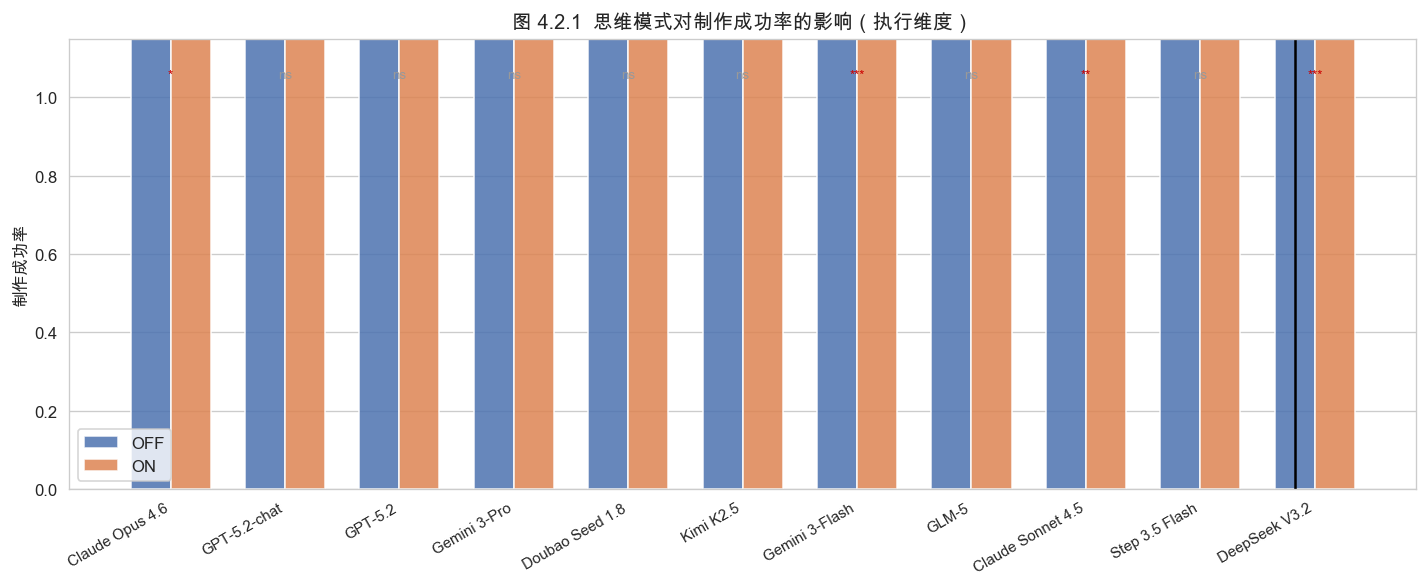

In [7]:
# ── 图 4.2.1：制作成功率 off vs on ──

craft_data = []
for m in paired_models:
    for t in ['off', 'on']:
        sub = df[(df['model']==m) & (df['thinking']==t)]
        craft_data.append({'model': m, 'thinking': t, 
                          'craft_success_rate': sub['craft_success_rate'].mean(),
                          'std': sub['craft_success_rate'].std()})
craft_df = pd.DataFrame(craft_data)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(paired_models))
w = 0.35
off_vals = craft_df[craft_df['thinking']=='off'].set_index('model').loc[paired_models]
on_vals = craft_df[craft_df['thinking']=='on'].set_index('model').loc[paired_models]

bars1 = ax.bar(x - w/2, off_vals['craft_success_rate'], w, label='OFF', color=PALETTE_THINK['off'],
               yerr=off_vals['std'], capsize=3, alpha=0.85)
bars2 = ax.bar(x + w/2, on_vals['craft_success_rate'], w, label='ON', color=PALETTE_THINK['on'],
               yerr=on_vals['std'], capsize=3, alpha=0.85)

# 显著性标注
for i, m in enumerate(paired_models):
    off_v = df[(df['model']==m) & (df['thinking']=='off')]['craft_success_rate'].dropna()
    on_v = df[(df['model']==m) & (df['thinking']=='on')]['craft_success_rate'].dropna()
    if len(off_v) > 1 and len(on_v) > 1:
        _, p = stats.mannwhitneyu(off_v, on_v, alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        top = max(off_vals.loc[m, 'craft_success_rate'], on_vals.loc[m, 'craft_success_rate'])
        ax.text(i, min(top + 0.08, 1.05), sig, ha='center', fontsize=8, color='#c00' if sig != 'ns' else '#999')

ax.set_xticks(x)
ax.set_xticklabels(paired_models, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('制作成功率')
ax.set_ylim(0, 1.15)
ax.legend()
ax.set_title('图 4.2.1  思维模式对制作成功率的影响（执行维度）')
plt.tight_layout()
fig.savefig(FIGURES / 'fig_4_2_1_craft_success.png', bbox_inches='tight')
plt.show()

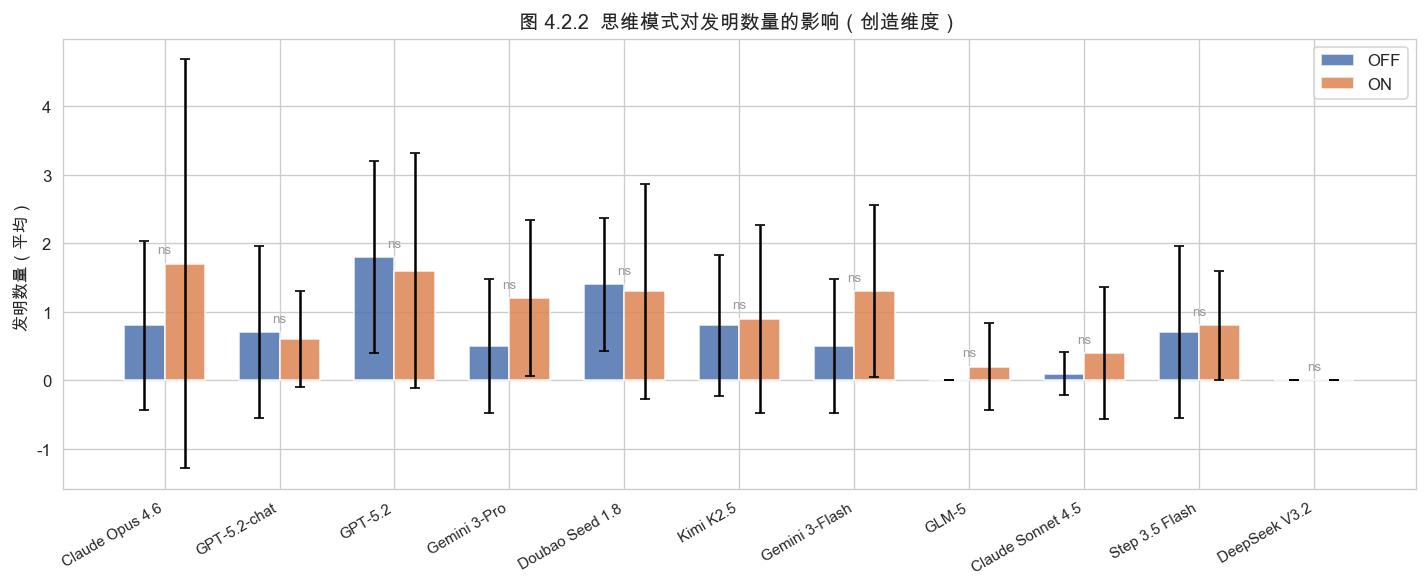

In [8]:
# ── 图 4.2.2：发明数量 off vs on ──

inv_data = []
for m in paired_models:
    for t in ['off', 'on']:
        sub = df[(df['model']==m) & (df['thinking']==t)]
        inv_data.append({'model': m, 'thinking': t,
                        'inventions': sub['inventions'].mean(),
                        'std': sub['inventions'].std()})
inv_df = pd.DataFrame(inv_data)

fig, ax = plt.subplots(figsize=(12, 5))
off_inv = inv_df[inv_df['thinking']=='off'].set_index('model').loc[paired_models]
on_inv = inv_df[inv_df['thinking']=='on'].set_index('model').loc[paired_models]

ax.bar(x - w/2, off_inv['inventions'], w, label='OFF', color=PALETTE_THINK['off'],
       yerr=off_inv['std'], capsize=3, alpha=0.85)
ax.bar(x + w/2, on_inv['inventions'], w, label='ON', color=PALETTE_THINK['on'],
       yerr=on_inv['std'], capsize=3, alpha=0.85)

for i, m in enumerate(paired_models):
    off_v = df[(df['model']==m) & (df['thinking']=='off')]['inventions']
    on_v = df[(df['model']==m) & (df['thinking']=='on')]['inventions']
    if len(off_v) > 1 and len(on_v) > 1:
        _, p = stats.mannwhitneyu(off_v, on_v, alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        top = max(off_inv.loc[m, 'inventions'], on_inv.loc[m, 'inventions'])
        ax.text(i, top + 0.15, sig, ha='center', fontsize=8, color='#c00' if sig != 'ns' else '#999')

ax.set_xticks(x)
ax.set_xticklabels(paired_models, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('发明数量（平均）')
ax.legend()
ax.set_title('图 4.2.2  思维模式对发明数量的影响（创造维度）')
plt.tight_layout()
fig.savefig(FIGURES / 'fig_4_2_2_inventions.png', bbox_inches='tight')
plt.show()

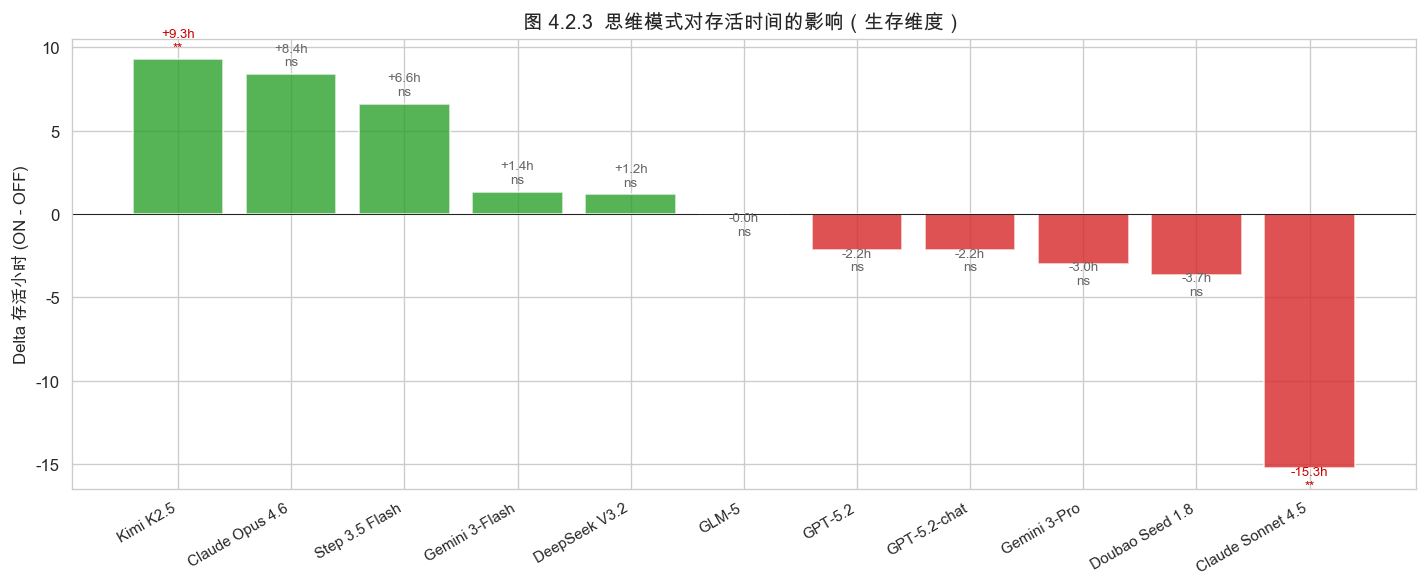


思维模式 delta 统计表：
| model             |   off_mean |   on_mean |   delta |   p | sig   |
|:------------------|-----------:|----------:|--------:|----:|:------|
| Kimi K2.5         |       43.5 |      52.8 |     9.3 | 0.0 | **    |
| Claude Opus 4.6   |       51.1 |      59.5 |     8.4 | 0.1 | ns    |
| Step 3.5 Flash    |       36.6 |      43.3 |     6.6 | 0.1 | ns    |
| Gemini 3-Flash    |       46.7 |      48.0 |     1.4 | 0.2 | ns    |
| DeepSeek V3.2     |       37.5 |      38.7 |     1.2 | 0.6 | ns    |
| GLM-5             |       47.4 |      47.3 |    -0.0 | 0.9 | ns    |
| GPT-5.2           |       53.4 |      51.2 |    -2.2 | 0.6 | ns    |
| GPT-5.2-chat      |       54.5 |      52.3 |    -2.2 | 0.9 | ns    |
| Gemini 3-Pro      |       50.7 |      47.7 |    -3.0 | 0.1 | ns    |
| Doubao Seed 1.8   |       50.9 |      47.2 |    -3.7 | 0.6 | ns    |
| Claude Sonnet 4.5 |       49.0 |      33.7 |   -15.3 | 0.0 | **    |


In [9]:
# ── 图 4.2.3：思维模式对存活时间的影响 delta ──

delta_data = []
for m in paired_models:
    off_h = df[(df['model']==m) & (df['thinking']=='off')]['hours_survived']
    on_h = df[(df['model']==m) & (df['thinking']=='on')]['hours_survived']
    delta = on_h.mean() - off_h.mean()
    # Mann-Whitney U test
    stat, p = stats.mannwhitneyu(off_h, on_h, alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    delta_data.append({'model': m, 'delta': delta, 'p': p, 'sig': sig,
                       'off_mean': off_h.mean(), 'on_mean': on_h.mean(),
                       'off_std': off_h.std(), 'on_std': on_h.std()})

delta_df = pd.DataFrame(delta_data).sort_values('delta', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ca02c' if d > 0 else '#d62728' for d in delta_df['delta']]
bars = ax.bar(range(len(delta_df)), delta_df['delta'], color=colors, alpha=0.8)
ax.set_xticks(range(len(delta_df)))
ax.set_xticklabels(delta_df['model'], rotation=30, ha='right', fontsize=9)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_ylabel('Delta 存活小时 (ON - OFF)')
ax.set_title('图 4.2.3  思维模式对存活时间的影响（生存维度）')

for i, (_, row) in enumerate(delta_df.iterrows()):
    ypos = row['delta'] + (0.5 if row['delta'] >= 0 else -1.2)
    ax.text(i, ypos, f"{row['delta']:+.1f}h\n{row['sig']}", ha='center', fontsize=8,
            color='#c00' if row['sig'] != 'ns' else '#666')

plt.tight_layout()
fig.savefig(FIGURES / 'fig_4_2_3_thinking_delta.png', bbox_inches='tight')
plt.show()

# 输出统计表
print('\n思维模式 delta 统计表：')
print(delta_df[['model', 'off_mean', 'on_mean', 'delta', 'p', 'sig']].to_markdown(index=False, floatfmt='.1f'))

In [10]:
# ── 表 4.2.4：思维模式影响汇总（4维度） ──

summary_rows = []
dims = [
    ('craft_success_rate', '执行（制作成功率）'),
    ('inventions', '创造（发明数量）'),
    ('hours_survived', '生存（存活时间）'),
    ('valid_rate', '格式遵循（有效率）'),
]
for col, dim_name in dims:
    pos, neg, ns_count = 0, 0, 0
    for m in paired_models:
        off_v = df[(df['model']==m) & (df['thinking']=='off')][col].dropna()
        on_v = df[(df['model']==m) & (df['thinking']=='on')][col].dropna()
        if len(off_v) < 2 or len(on_v) < 2:
            continue
        _, p = stats.mannwhitneyu(off_v, on_v, alternative='two-sided')
        if p < 0.05:
            if on_v.mean() > off_v.mean():
                pos += 1
            else:
                neg += 1
        else:
            ns_count += 1
    summary_rows.append({'维度': dim_name, '显著正向': pos, '显著负向': neg, '无显著': ns_count,
                        '方向一致性': '一致' if (pos==0 or neg==0) and ns_count < len(paired_models)//2 else '不一致'})

print(pd.DataFrame(summary_rows).to_markdown(index=False))

| 维度               |   显著正向 |   显著负向 |   无显著 | 方向一致性   |
|:-------------------|-----------:|-----------:|---------:|:-------------|
| 执行（制作成功率） |          4 |          0 |        7 | 不一致       |
| 创造（发明数量）   |          0 |          0 |       11 | 不一致       |
| 生存（存活时间）   |          1 |          1 |        9 | 不一致       |
| 格式遵循（有效率） |          1 |          1 |        9 | 不一致       |


---
## 4.3 行为策略与阶段演化

需要从 JSONL 原始数据中提取逐 tick 的动作序列。

In [11]:
# ── 加载所有 JSONL tick 数据 ──

def load_ticks(player_tag):
    """加载某个 player_tag 的所有 tick 数据"""
    tag_dir = RESULTS / player_tag
    all_ticks = []
    for jf in sorted(tag_dir.glob('*.jsonl')):
        run_id = jf.stem  # e.g. run_1
        with open(jf) as f:
            for line in f:
                rec = json.loads(line)
                if rec.get('type') == 'final_score':
                    continue
                rec['run_id'] = run_id
                rec['player_tag'] = player_tag
                all_ticks.append(rec)
    return all_ticks

# 加载所有配置的 tick 数据
all_ticks = {}
for tag in sorted(df['player_tag'].unique()):
    all_ticks[tag] = load_ticks(tag)
    
# 也加载 qwen3_max_on（案例研究）
qwen3_on_dir = RESULTS / 'qwen3_max_on'
if qwen3_on_dir.exists():
    all_ticks['qwen3_max_on'] = load_ticks('qwen3_max_on')

print(f'Loaded tick data for {len(all_ticks)} configs')
for tag, ticks in sorted(all_ticks.items()):
    print(f'  {tag}: {len(ticks)} ticks')

Loaded tick data for 24 configs
  claude_opus_off: 584 ticks
  claude_opus_on: 580 ticks
  claude_sonnet_off: 507 ticks
  claude_sonnet_on: 372 ticks
  deepseek_v32_off: 804 ticks
  deepseek_v32_on: 445 ticks
  doubao-v18_off: 469 ticks
  doubao-v18_on: 441 ticks
  gemini_3_flash_high: 459 ticks
  gemini_3_flash_off: 469 ticks
  gemini_3_pro_high: 496 ticks
  gemini_3_pro_off: 546 ticks
  glm_5_off: 620 ticks
  glm_5_on: 627 ticks
  gpt52_chat_off: 558 ticks
  gpt52_chat_on: 545 ticks
  gpt52_off: 523 ticks
  gpt52_on: 505 ticks
  kimi_25_off: 453 ticks
  kimi_25_on: 492 ticks
  qwen3_max_off: 764 ticks
  qwen3_max_on: 1017 ticks
  step_35_flash_off: 431 ticks
  step_35_flash_on: 454 ticks


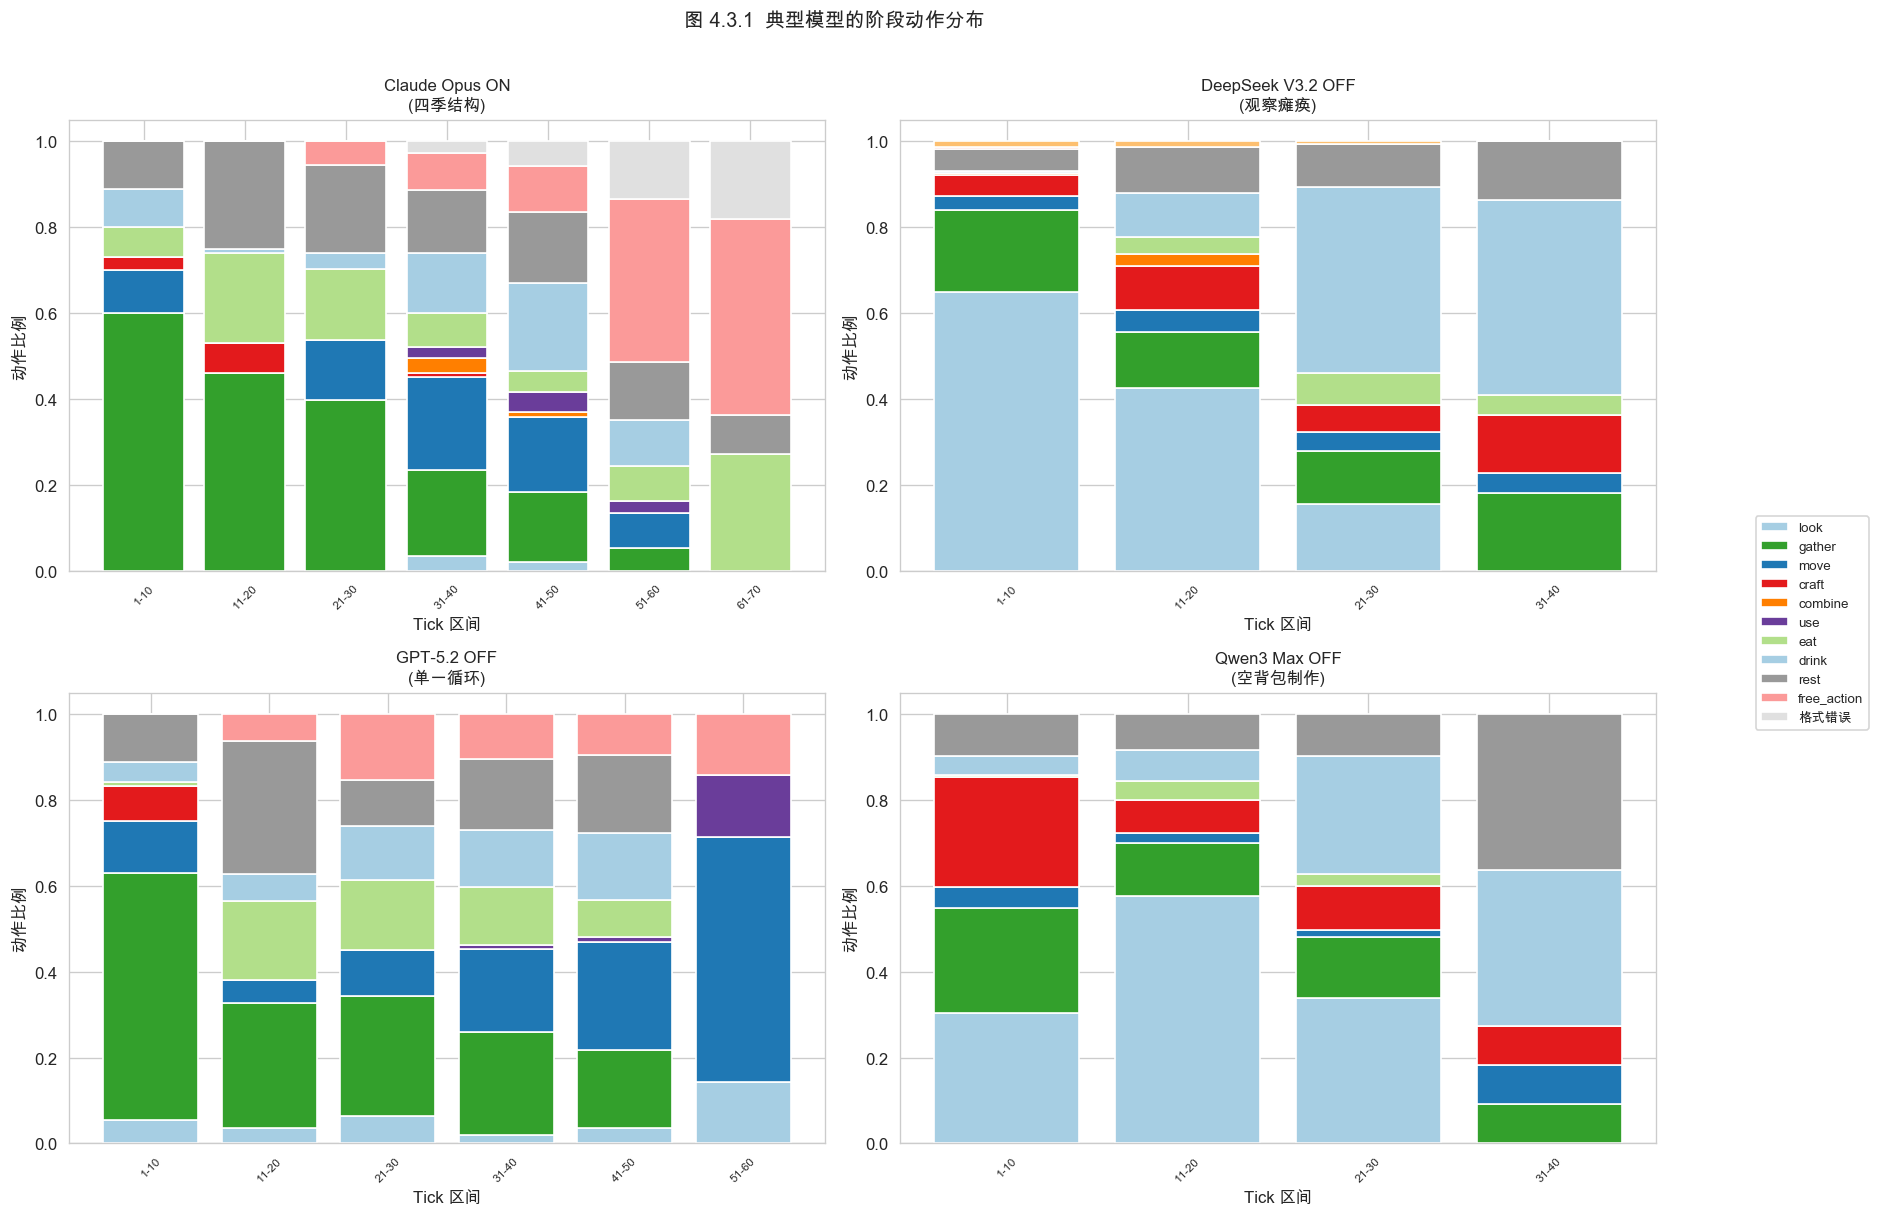

In [12]:
# ── 图 4.3.1：阶段动作分布（典型模型对比） ──

def phase_action_distribution(ticks, phase_size=10):
    """按 tick 区间统计动作类型分布"""
    phases = defaultdict(lambda: Counter())
    for t in ticks:
        tick_num = t.get('tick', 0)
        if tick_num <= 0:
            continue
        phase = ((tick_num - 1) // phase_size) * phase_size + 1
        action = t.get('action_type', 'unknown')
        phases[phase][action] += 1
    return dict(phases)

# 选择典型模型
showcase_tags = ['claude_opus_on', 'deepseek_v32_off', 'gpt52_off', 'qwen3_max_off']
showcase_names = ['Claude Opus ON\n(四季结构)', 'DeepSeek V3.2 OFF\n(观察瘫痪)', 
                  'GPT-5.2 OFF\n(单一循环)', 'Qwen3 Max OFF\n(空背包制作)']

# 关键动作类型
ACTION_TYPES = ['look', 'gather', 'move', 'craft', 'combine', 'use', 'eat', 'drink', 'rest', 'free_action', 'note']
ACTION_COLORS = {
    'look': '#a6cee3', 'gather': '#33a02c', 'move': '#1f78b4', 
    'craft': '#e31a1c', 'combine': '#ff7f00', 'use': '#6a3d9a',
    'eat': '#b2df8a', 'drink': '#a6cee3', 'rest': '#999999',
    'free_action': '#fb9a99', 'note': '#fdbf6f', 'other': '#cccccc'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, (tag, name) in enumerate(zip(showcase_tags, showcase_names)):
    ax = axes[idx // 2][idx % 2]
    ticks = all_ticks.get(tag, [])
    if not ticks:
        ax.set_title(f'{name}\n(无数据)')
        continue
    
    phases = phase_action_distribution(ticks)
    phase_keys = sorted(phases.keys())
    if len(phase_keys) == 0:
        continue
    
    # 构建堆叠数据
    bottom = np.zeros(len(phase_keys))
    for act in ACTION_TYPES:
        vals = [phases[p].get(act, 0) for p in phase_keys]
        totals = [sum(phases[p].values()) for p in phase_keys]
        ratios = [v/t if t > 0 else 0 for v, t in zip(vals, totals)]
        if sum(ratios) > 0:
            ax.bar(range(len(phase_keys)), ratios, bottom=bottom, 
                   label=act, color=ACTION_COLORS.get(act, '#ccc'), width=0.8)
            bottom += ratios
    
    # "other" for empty/unknown
    other_ratios = [1 - b for b in bottom]
    if any(r > 0.01 for r in other_ratios):
        ax.bar(range(len(phase_keys)), other_ratios, bottom=bottom,
               label='格式错误', color='#e0e0e0', width=0.8)
    
    ax.set_xticks(range(len(phase_keys)))
    ax.set_xticklabels([f'{p}-{p+9}' for p in phase_keys], fontsize=7, rotation=45)
    ax.set_xlabel('Tick 区间')
    ax.set_ylabel('动作比例')
    ax.set_title(name, fontsize=10)
    ax.set_ylim(0, 1.05)

# 统一图例
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5), fontsize=8)
fig.suptitle('图 4.3.1  典型模型的阶段动作分布', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES / 'fig_4_3_1_phase_strategy.png', bbox_inches='tight')
plt.show()

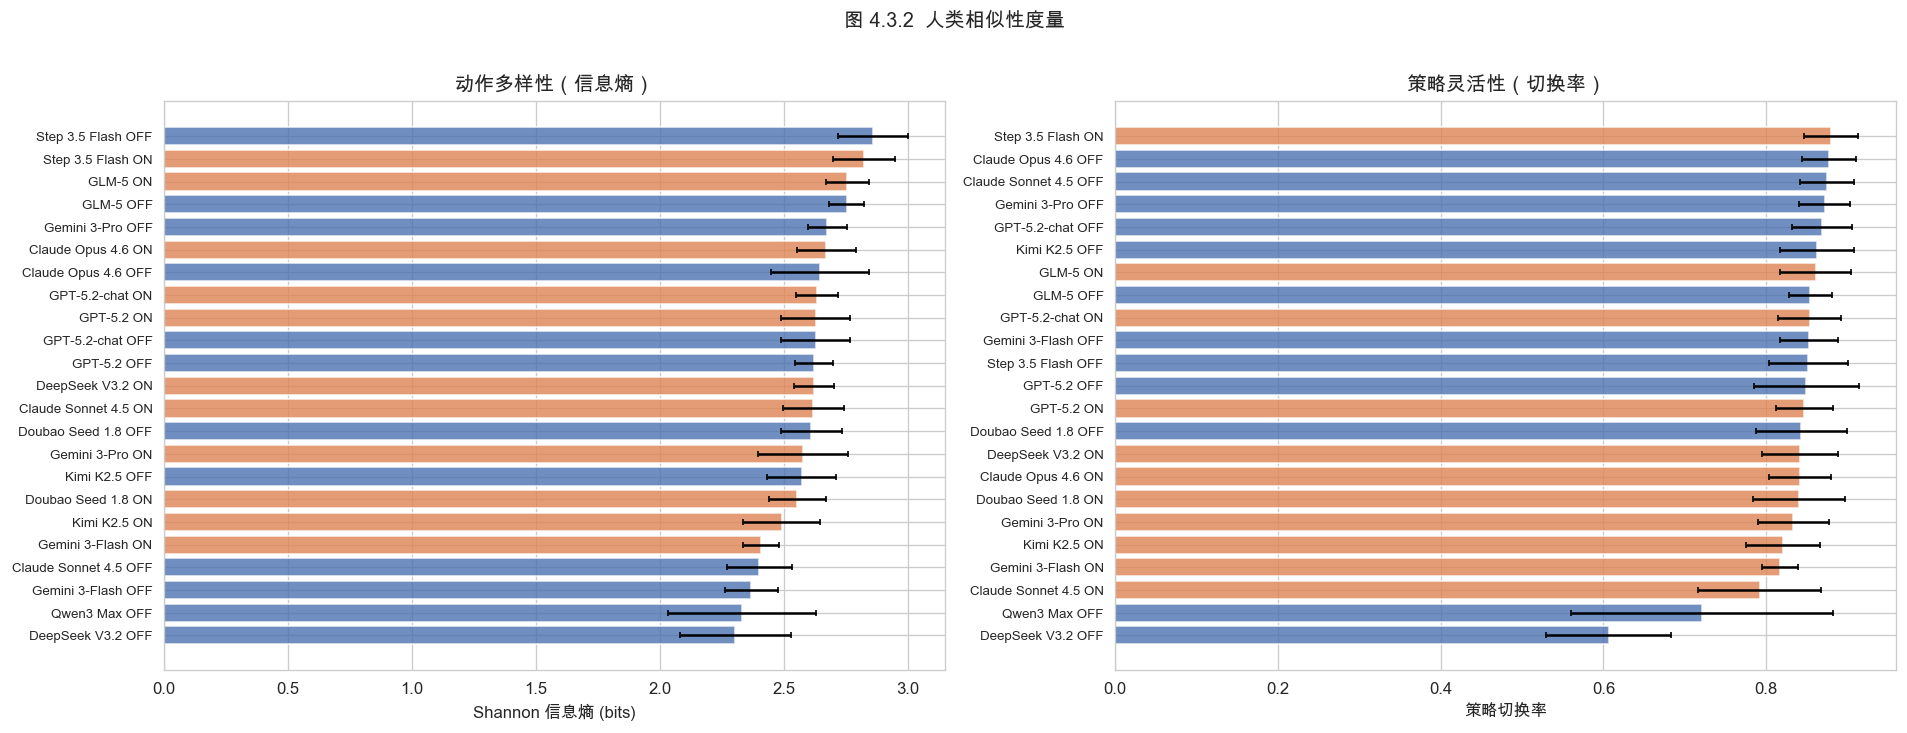

In [13]:
# ── 图 4.3.2：信息熵和策略切换率 ──

def calculate_entropy(ticks):
    """计算动作类型分布的 Shannon 信息熵"""
    actions = [t.get('action_type', 'unknown') for t in ticks if t.get('tick', 0) > 0]
    if not actions:
        return 0
    counts = Counter(actions)
    total = sum(counts.values())
    probs = [c / total for c in counts.values()]
    return -sum(p * np.log2(p) for p in probs if p > 0)

def calculate_switch_rate(ticks):
    """计算相邻动作类型变化的比例"""
    actions = [t.get('action_type', 'unknown') for t in ticks if t.get('tick', 0) > 0]
    if len(actions) < 2:
        return 0
    switches = sum(1 for i in range(1, len(actions)) if actions[i] != actions[i-1])
    return switches / (len(actions) - 1)

behavior_data = []
for tag in sorted(all_ticks.keys()):
    if tag == 'qwen3_max_on':  # 排除案例研究
        continue
    info = TAG_MAP.get(tag)
    if not info:
        continue
    model, thinking = info
    
    # 按 run 分别计算，取均值
    ticks = all_ticks[tag]
    by_run = defaultdict(list)
    for t in ticks:
        by_run[t['run_id']].append(t)
    
    entropies = [calculate_entropy(run_ticks) for run_ticks in by_run.values()]
    switch_rates = [calculate_switch_rate(run_ticks) for run_ticks in by_run.values()]
    
    behavior_data.append({
        'tag': tag, 'model': model, 'thinking': thinking,
        'label': f'{model} {thinking.upper()}',
        'entropy_mean': np.mean(entropies),
        'entropy_std': np.std(entropies),
        'switch_mean': np.mean(switch_rates),
        'switch_std': np.std(switch_rates),
    })

beh_df = pd.DataFrame(behavior_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 信息熵排名
beh_sorted = beh_df.sort_values('entropy_mean', ascending=True)
colors = [PALETTE_THINK[r['thinking']] for _, r in beh_sorted.iterrows()]
ax1.barh(range(len(beh_sorted)), beh_sorted['entropy_mean'], 
         xerr=beh_sorted['entropy_std'], color=colors, alpha=0.8, capsize=2)
ax1.set_yticks(range(len(beh_sorted)))
ax1.set_yticklabels(beh_sorted['label'], fontsize=8)
ax1.set_xlabel('Shannon 信息熵 (bits)')
ax1.set_title('动作多样性（信息熵）')

# 策略切换率排名
beh_sorted2 = beh_df.sort_values('switch_mean', ascending=True)
colors2 = [PALETTE_THINK[r['thinking']] for _, r in beh_sorted2.iterrows()]
ax2.barh(range(len(beh_sorted2)), beh_sorted2['switch_mean'],
         xerr=beh_sorted2['switch_std'], color=colors2, alpha=0.8, capsize=2)
ax2.set_yticks(range(len(beh_sorted2)))
ax2.set_yticklabels(beh_sorted2['label'], fontsize=8)
ax2.set_xlabel('策略切换率')
ax2.set_title('策略灵活性（切换率）')

fig.suptitle('图 4.3.2  人类相似性度量', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES / 'fig_4_3_2_human_likeness.png', bbox_inches='tight')
plt.show()

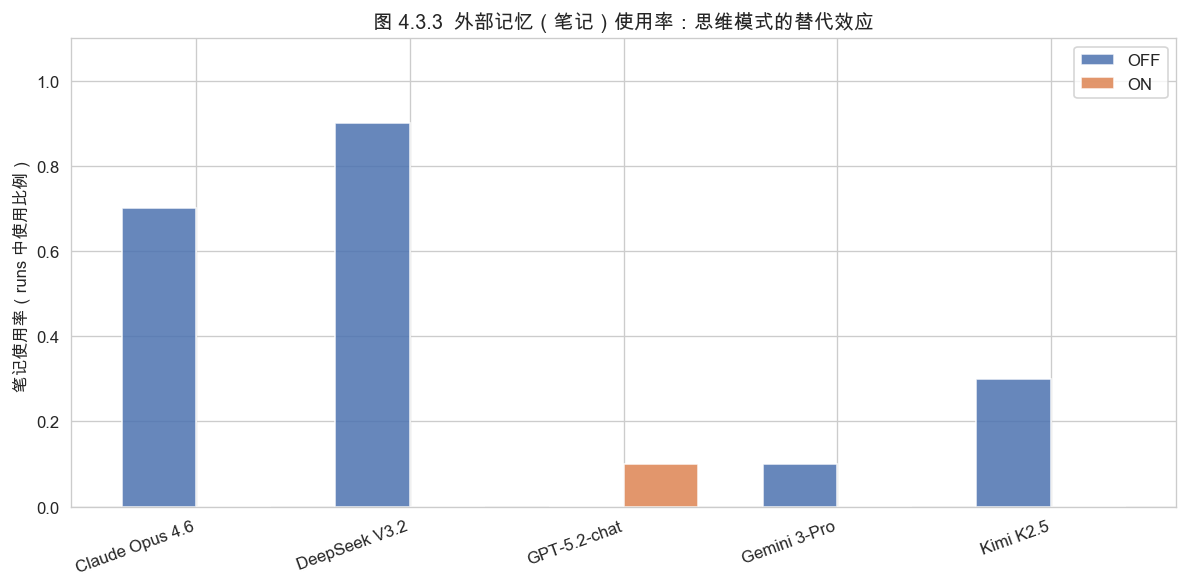


笔记使用统计：
| model           | thinking   |   usage_rate |   total_notes |   runs_with_notes |
|:----------------|:-----------|-------------:|--------------:|------------------:|
| Claude Opus 4.6 | off        |          70% |             7 |                 7 |
| DeepSeek V3.2   | off        |          90% |             9 |                 9 |
| Gemini 3-Pro    | off        |          10% |             1 |                 1 |
| GPT-5.2-chat    | on         |          10% |             1 |                 1 |
| Kimi K2.5       | off        |          30% |             3 |                 3 |


In [14]:
# ── 图 4.3.3：笔记使用率分析 ──

note_data = []
for tag in sorted(all_ticks.keys()):
    if tag == 'qwen3_max_on':
        continue
    info = TAG_MAP.get(tag)
    if not info:
        continue
    model, thinking = info
    
    ticks = all_ticks[tag]
    by_run = defaultdict(list)
    for t in ticks:
        by_run[t['run_id']].append(t)
    
    runs_with_notes = 0
    total_notes = 0
    for run_id, run_ticks in by_run.items():
        has_note = any(t.get('action_type') == 'note' for t in run_ticks)
        note_count = sum(1 for t in run_ticks if t.get('action_type') == 'note')
        if has_note:
            runs_with_notes += 1
        total_notes += note_count
    
    n_runs = len(by_run)
    note_data.append({
        'model': model, 'thinking': thinking,
        'label': f'{model} {thinking.upper()}',
        'usage_rate': runs_with_notes / n_runs if n_runs > 0 else 0,
        'total_notes': total_notes,
        'runs_with_notes': runs_with_notes,
        'n_runs': n_runs,
    })

note_df = pd.DataFrame(note_data)

# 只显示至少一个模式用过笔记的模型
models_with_notes = note_df[note_df['total_notes'] > 0]['model'].unique()
note_show = note_df[note_df['model'].isin(models_with_notes)].copy()

if len(note_show) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    models_list = sorted(note_show['model'].unique())
    x = np.arange(len(models_list))
    w = 0.35
    
    for i, t in enumerate(['off', 'on']):
        vals = []
        for m in models_list:
            row = note_show[(note_show['model']==m) & (note_show['thinking']==t)]
            vals.append(row['usage_rate'].values[0] if len(row) > 0 else 0)
        offset = -w/2 if t == 'off' else w/2
        ax.bar(x + offset, vals, w, label=t.upper(), color=PALETTE_THINK[t], alpha=0.85)
    
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=20, ha='right')
    ax.set_ylabel('笔记使用率（runs 中使用比例）')
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.set_title('图 4.3.3  外部记忆（笔记）使用率：思维模式的替代效应')
    plt.tight_layout()
    fig.savefig(FIGURES / 'fig_4_3_3_notebook_usage.png', bbox_inches='tight')
    plt.show()
else:
    print('没有模型使用过笔记功能')

# 输出完整数据
print('\n笔记使用统计：')
print(note_df[note_df['total_notes'] > 0][['model', 'thinking', 'usage_rate', 'total_notes', 'runs_with_notes']].to_markdown(index=False, floatfmt='.0%'))

---
## 4.4 创造力涌现

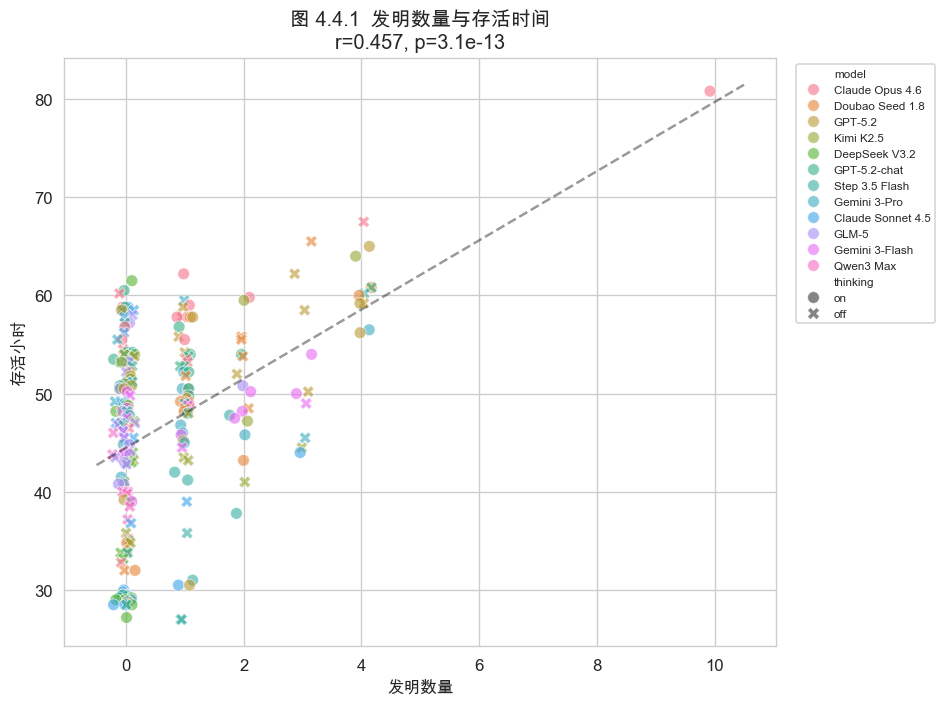

In [15]:
# ── 图 4.4.1：发明数量 vs 存活时间散点图 ──

fig, ax = plt.subplots(figsize=(8, 6))
# 抖动处理（inventions 是整数，会重叠）
jitter = np.random.normal(0, 0.08, len(df))
sns.scatterplot(data=df, x=df['inventions'] + jitter, y='hours_survived',
                hue='model', style='thinking', alpha=0.6, s=50, ax=ax)

r, p = stats.pearsonr(df['inventions'], df['hours_survived'])
z = np.polyfit(df['inventions'], df['hours_survived'], 1)
xs = np.linspace(-0.5, df['inventions'].max() + 0.5, 50)
ax.plot(xs, np.polyval(z, xs), 'k--', alpha=0.4)
ax.set_xlabel('发明数量')
ax.set_ylabel('存活小时')
ax.set_title(f'图 4.4.1  发明数量与存活时间\nr={r:.3f}, p={p:.1e}')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=1)
plt.tight_layout()
fig.savefig(FIGURES / 'fig_4_4_1_inventions_survival.png', bbox_inches='tight')
plt.show()

In [16]:
# ── 图 4.4.2：发明多样性 —— 从 JSONL 提取实际发明内容 ──

def extract_inventions(ticks):
    """从 tick 数据中提取发明名称"""
    inventions = []
    for t in ticks:
        items_gained = t.get('items_gained', [])
        for item in items_gained:
            # 发明通常是 LLM 裁判判定的新配方
            if t.get('needs_llm') or t.get('action_type') in ('combine', 'free_action'):
                if isinstance(item, dict):
                    inventions.append(item.get('name', item.get('item_id', str(item))))
                elif isinstance(item, str):
                    inventions.append(item)
    return inventions

invention_summary = []
for tag in sorted(all_ticks.keys()):
    if tag == 'qwen3_max_on':
        continue
    info = TAG_MAP.get(tag)
    if not info:
        continue
    model, thinking = info
    invs = extract_inventions(all_ticks[tag])
    inv_counter = Counter(invs)
    invention_summary.append({
        'model': model, 'thinking': thinking,
        'total_inventions': len(invs),
        'unique_inventions': len(inv_counter),
        'top_inventions': inv_counter.most_common(5),
    })

inv_sum_df = pd.DataFrame(invention_summary)
print('发明多样性统计：')
for _, row in inv_sum_df.sort_values('unique_inventions', ascending=False).iterrows():
    print(f"  {row['model']} {row['thinking'].upper()}: {row['unique_inventions']} 种 / {row['total_inventions']} 总")
    if row['top_inventions']:
        for name, count in row['top_inventions']:
            print(f"    - {name}: {count}次")

发明多样性统计：
  GPT-5.2 ON: 15 种 / 16 总
    - 盛水的聚合物板 [耐久 10/10]: 2次
    - 盛露水的聚合物板 [耐久 1/1]: 1次
    - 简易庇护所 [耐久 50/50]: 1次
    - 生黏土杯 [耐久 3/3]: 1次
    - 装水的生黏土杯 [耐久 2/2]: 1次
  Claude Opus 4.6 ON: 15 种 / 17 总
    - 一碗露水 [耐久 1/1]: 2次
    - 藤蔓汁液 [耐久 1/1]: 2次
    - 简易苔藓滤芯 [耐久 5/5]: 1次
    - 树脂火把 [耐久 15/15]: 1次
    - 简易苔藓滤水器 [耐久 5/5]: 1次
  Doubao Seed 1.8 OFF: 14 种 / 14 总
    - 露水 [耐久 1/1]: 1次
    - 盛水的聚合物板 [耐久 5/5]: 1次
    - 盛水的聚合物板 [耐久 1/1]: 1次
    - 吸满水的苔藓 [耐久 1/1]: 1次
    - 吸饱水的苔藓 [耐久 1/1]: 1次
  GPT-5.2 OFF: 14 种 / 18 总
    - 盛水的聚合物板 [耐久 1/1]: 3次
    - 简易庇护所 [耐久 50/50]: 2次
    - 简易滤水器 [耐久 5/5]: 2次
    - 简易过滤水 [耐久 1/1]: 1次
    - 简易钛刃斧 [耐久 20/20]: 1次
  Gemini 3-Flash ON: 13 种 / 13 总
    - 树脂密封黏土罐(装满水) [耐久 5/5]: 1次
    - 未烧制的黏土碗 [耐久 5/5]: 1次
    - 简易过滤吸管 [耐久 5/5]: 1次
    - 简易合金斧 [耐久 20/20]: 1次
    - 浑浊的地下水坑 [耐久 1/1]: 1次
  Gemini 3-Pro ON: 11 种 / 12 总
    - 简易火把 [耐久 5/5]: 2次
    - 简易合金匕首 [耐久 15/15]: 1次
    - 盛水的聚合物板 [耐久 10/10]: 1次
    - 简易合金长矛 [耐久 15/15]: 1次
    - 盛水的聚合物板 [耐久 1/1]: 1次
  Doubao 

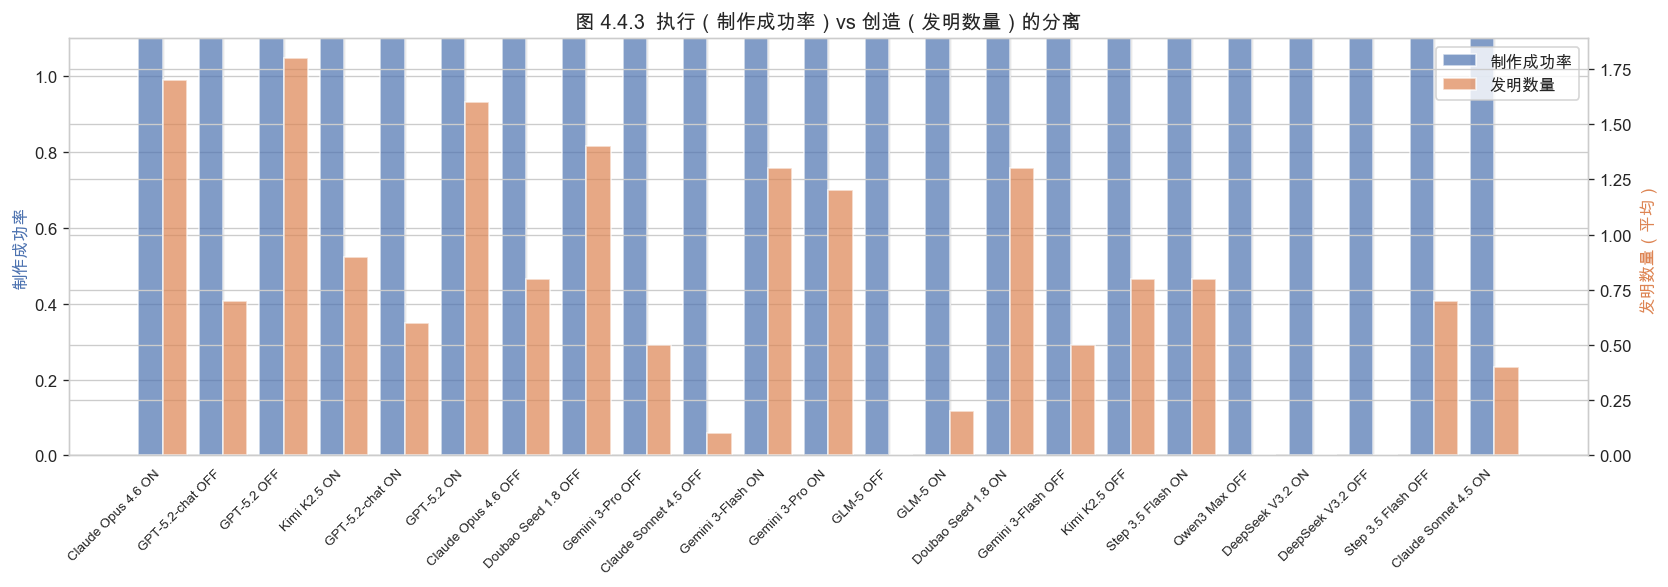

In [17]:
# ── 图 4.4.3：制作成功率 vs 发明数量（双 Y 轴，执行 vs 创造分离） ──

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

agg = df.groupby('label').agg(
    craft_rate=('craft_success_rate', 'mean'),
    inv_mean=('inventions', 'mean'),
).loc[order]  # 按存活时间排序

x = np.arange(len(agg))
ax1.bar(x - 0.2, agg['craft_rate'], 0.4, color='#4C72B0', alpha=0.7, label='制作成功率')
ax2.bar(x + 0.2, agg['inv_mean'], 0.4, color='#DD8452', alpha=0.7, label='发明数量')

ax1.set_xticks(x)
ax1.set_xticklabels(agg.index, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('制作成功率', color='#4C72B0')
ax2.set_ylabel('发明数量（平均）', color='#DD8452')
ax1.set_ylim(0, 1.1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('图 4.4.3  执行（制作成功率）vs 创造（发明数量）的分离')
plt.tight_layout()
fig.savefig(FIGURES / 'fig_4_4_3_execution_vs_creation.png', bbox_inches='tight')
plt.show()

---
## 4.5 成本效益分析

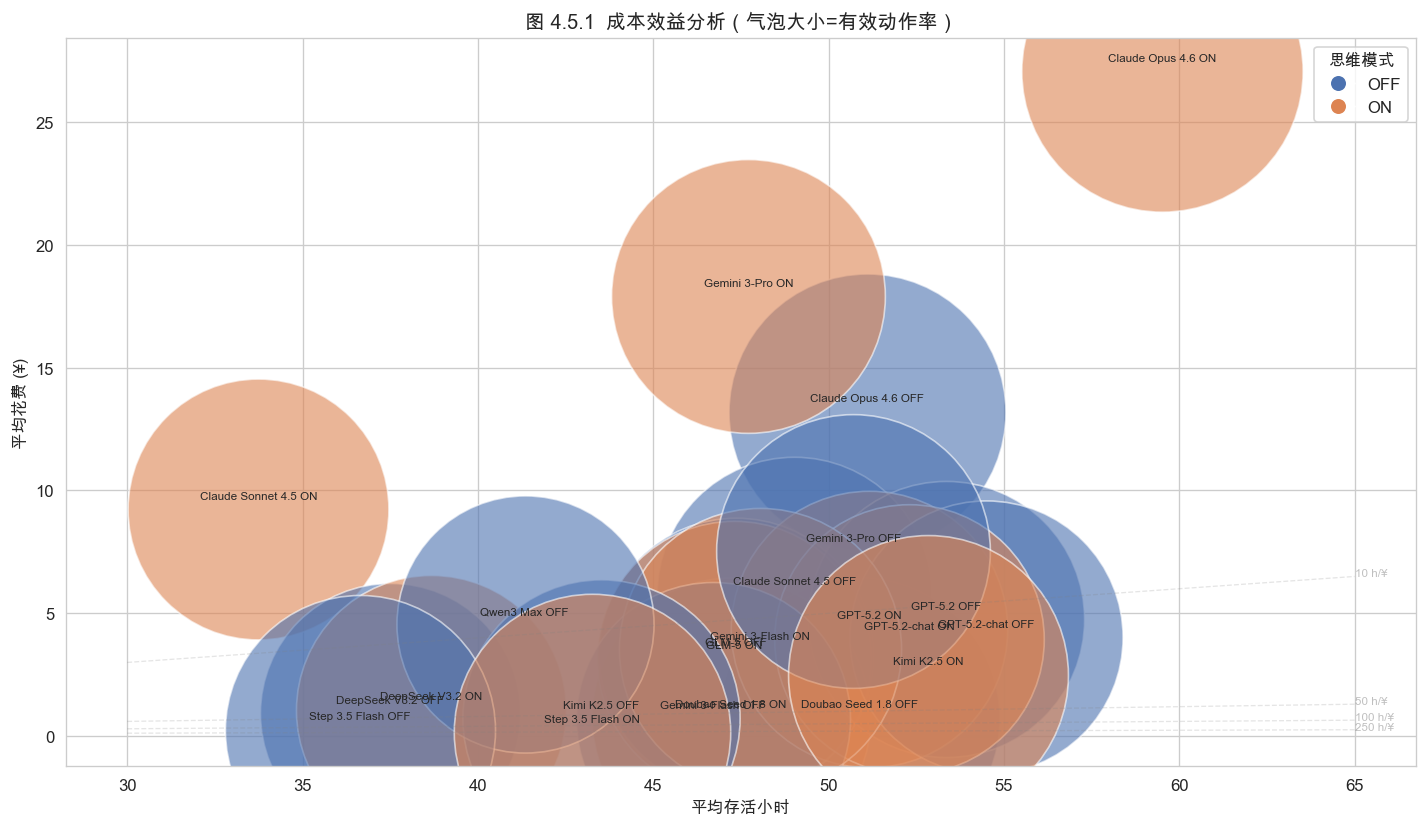


性价比排名（h/¥）：
| label                 |   hours_mean |   cost_mean |   cost_perf |
|:----------------------|-------------:|------------:|------------:|
| Step 3.5 Flash ON     |         43.3 |         0.2 |       262.0 |
| Step 3.5 Flash OFF    |         36.6 |         0.3 |       140.7 |
| Doubao Seed 1.8 OFF   |         50.9 |         0.7 |        68.2 |
| Gemini 3-Flash OFF    |         46.7 |         0.7 |        65.3 |
| Doubao Seed 1.8 ON    |         47.2 |         0.8 |        61.3 |
| Kimi K2.5 OFF         |         43.5 |         0.7 |        59.0 |
| DeepSeek V3.2 OFF     |         37.5 |         0.9 |        40.5 |
| DeepSeek V3.2 ON      |         38.7 |         1.1 |        36.0 |
| Kimi K2.5 ON          |         52.8 |         2.5 |        21.1 |
| GLM-5 ON              |         47.3 |         3.2 |        14.9 |
| GLM-5 OFF             |         47.4 |         3.3 |        14.3 |
| Gemini 3-Flash ON     |         48.0 |         3.5 |        13.6 |
| GPT-5.2-chat OFF   

In [18]:
# ── 图 4.5.1：成本效益气泡图 ──

cost_agg = df.groupby(['label', 'model', 'thinking']).agg(
    hours_mean=('hours_survived', 'mean'),
    cost_mean=('cost_cny', 'mean'),
    valid_mean=('valid_rate', 'mean'),
).reset_index()
cost_agg['cost_perf'] = cost_agg['hours_mean'] / cost_agg['cost_mean'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(12, 7))
for _, row in cost_agg.iterrows():
    color = PALETTE_THINK[row['thinking']]
    size = row['valid_mean'] * 300  # 气泡大小 = 有效率
    ax.scatter(row['hours_mean'], row['cost_mean'], s=size, c=color, alpha=0.6, edgecolors='white')
    ax.annotate(row['label'], (row['hours_mean'], row['cost_mean']),
                fontsize=7, ha='center', va='bottom', 
                xytext=(0, 5), textcoords='offset points')

ax.set_xlabel('平均存活小时')
ax.set_ylabel('平均花费 (¥)')
ax.set_title('图 4.5.1  成本效益分析（气泡大小=有效动作率）')

# 等性价比线
for ratio in [10, 50, 100, 250]:
    xs = np.linspace(30, 65, 50)
    ax.plot(xs, xs / ratio, '--', alpha=0.2, color='gray', linewidth=0.8)
    ax.text(65, 65/ratio, f'{ratio} h/¥', fontsize=7, color='gray', alpha=0.5)

# 图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=PALETTE_THINK['off'], markersize=10, label='OFF'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=PALETTE_THINK['on'], markersize=10, label='ON'),
]
ax.legend(handles=legend_elements, title='思维模式')

plt.tight_layout()
fig.savefig(FIGURES / 'fig_4_5_1_cost_performance.png', bbox_inches='tight')
plt.show()

# 性价比排名表
print('\n性价比排名（h/¥）：')
print(cost_agg.sort_values('cost_perf', ascending=False)[['label', 'hours_mean', 'cost_mean', 'cost_perf']].to_markdown(index=False, floatfmt='.1f'))

---
## 4.6 案例研究：Qwen3 Max 思维模式崩溃

Qwen3 Max On: 1017 ticks 分类结果：
  OTHER_GARBLE: 299 (29.4%)
  EXTRA_TEXT: 296 (29.1%)
  TAG_SHATTER: 180 (17.7%)
  EMPTY_OUTPUT: 96 (9.4%)
  WRONG_XML_WRAPPER: 70 (6.9%)
  PARTIAL_CORRECT: 25 (2.5%)
  SUCCESS: 25 (2.5%)
  HTML_ENTITY_GARBLE: 17 (1.7%)
  REASONING_LEAK: 9 (0.9%)


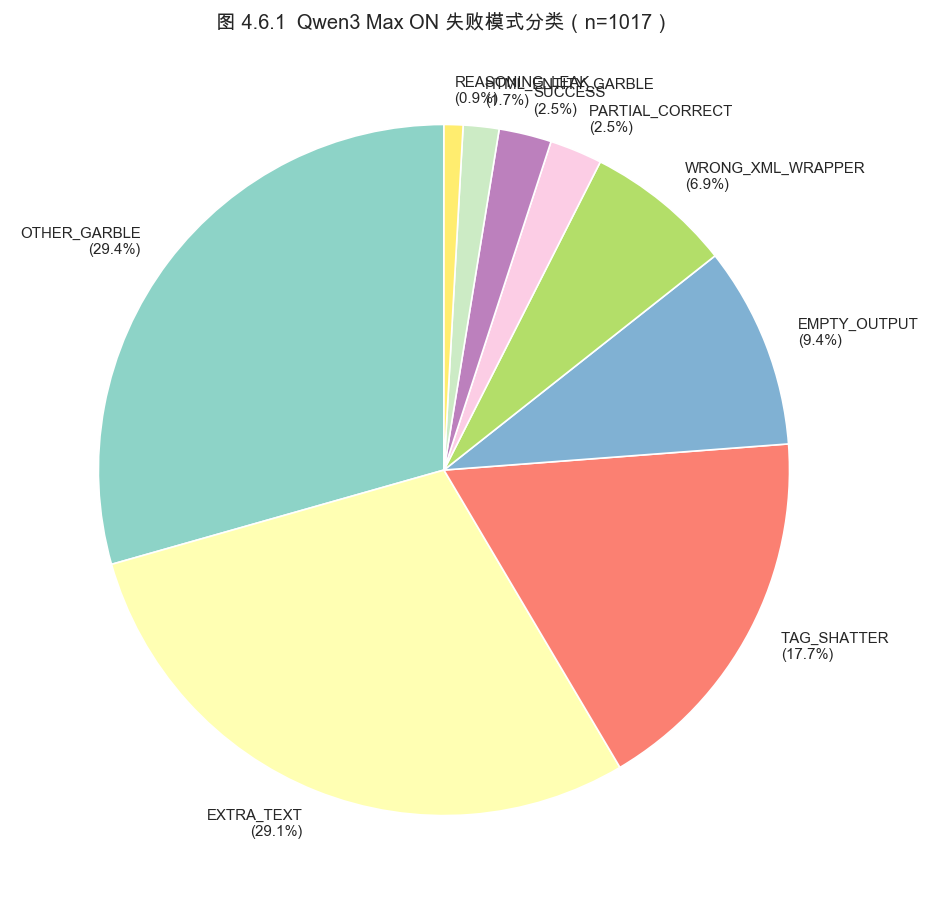

In [19]:
# ── 图 4.6.1：失败模式分类 ──

import re

def classify_failure(tick):
    """分类 Qwen3 Max On 的失败模式"""
    raw = tick.get('llm_raw_output', '') or ''
    action_type = tick.get('action_type', '')
    success = tick.get('success', False)
    
    # 成功
    if action_type not in ('empty', 'unknown', '') and success is not False:
        if re.search(r'<action>.*</action>', raw):
            return 'SUCCESS'
    
    if not raw or raw.strip() == '':
        return 'EMPTY_OUTPUT'
    
    # 推理泄漏
    if any(kw in raw for kw in ['我需要', '让我想', '分析一下', '首先', '接下来我应该', '思考']):
        if len(raw) > 200:
            return 'REASONING_LEAK'
    
    # 错误 XML 标签
    if re.search(r'<(?!action|detail)[a-zA-Z]+>', raw) and '<action>' not in raw:
        return 'WRONG_XML_WRAPPER'
    
    # 标签碎裂
    if '<act' in raw and '</action>' not in raw:
        return 'TAG_SHATTER'
    if '<action>' in raw and '</action>' not in raw:
        return 'TAG_SHATTER'
    
    # HTML 实体
    if '&lt;' in raw or '&gt;' in raw:
        return 'HTML_ENTITY_GARBLE'
    
    # 有正确 XML 但前后有多余文本
    if '<action>' in raw and '</action>' in raw:
        before = raw[:raw.index('<action>')].strip()
        after_match = re.search(r'</(?:detail|action)>', raw)
        if before or (after_match and raw[after_match.end():].strip()):
            return 'EXTRA_TEXT'
        return 'PARTIAL_CORRECT'
    
    return 'OTHER_GARBLE'

qwen_on_ticks = all_ticks.get('qwen3_max_on', [])
if qwen_on_ticks:
    classifications = [classify_failure(t) for t in qwen_on_ticks]
    class_counts = Counter(classifications)
    total = len(classifications)
    
    print(f'Qwen3 Max On: {total} ticks 分类结果：')
    for cls, cnt in class_counts.most_common():
        print(f'  {cls}: {cnt} ({cnt/total*100:.1f}%)')
    
    # 饼图
    fig, ax = plt.subplots(figsize=(8, 8))
    labels_pie = [f'{cls}\n({cnt/total*100:.1f}%)' for cls, cnt in class_counts.most_common()]
    sizes = [cnt for _, cnt in class_counts.most_common()]
    colors_pie = plt.cm.Set3(np.linspace(0, 1, len(sizes)))
    
    wedges, texts, autotexts = ax.pie(sizes, labels=labels_pie, colors=colors_pie,
                                       autopct='', startangle=90, pctdistance=0.85)
    for text in texts:
        text.set_fontsize(9)
    ax.set_title(f'图 4.6.1  Qwen3 Max ON 失败模式分类（n={total}）')
    plt.tight_layout()
    fig.savefig(FIGURES / 'fig_4_6_1_qwen_failure_modes.png', bbox_inches='tight')
    plt.show()
else:
    print('未找到 qwen3_max_on 的 tick 数据')

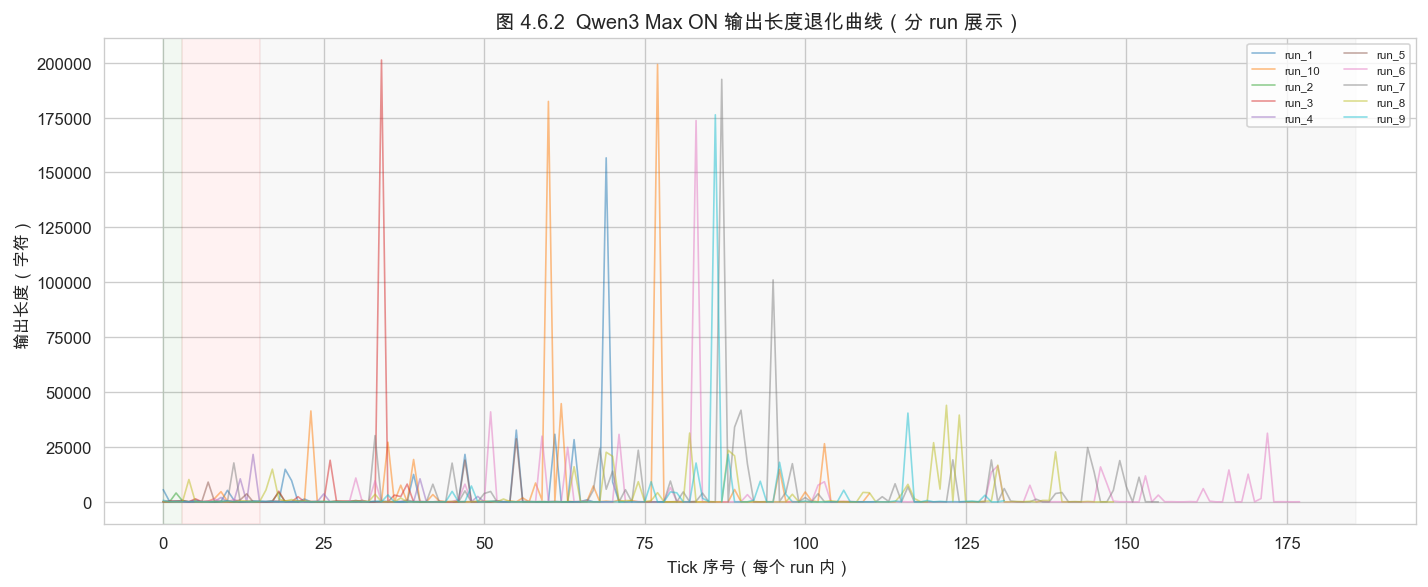

In [20]:
# ── 图 4.6.2：输出长度退化曲线 ──

if qwen_on_ticks:
    # 按 run 分组
    qwen_by_run = defaultdict(list)
    for t in qwen_on_ticks:
        qwen_by_run[t['run_id']].append(t)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    for run_id, run_ticks in sorted(qwen_by_run.items()):
        tick_nums = [t.get('tick', i) for i, t in enumerate(run_ticks)]
        lengths = [len(t.get('llm_raw_output', '') or '') for t in run_ticks]
        ax.plot(range(len(lengths)), lengths, alpha=0.5, linewidth=1, label=run_id)
    
    ax.set_xlabel('Tick 序号（每个 run 内）')
    ax.set_ylabel('输出长度（字符）')
    ax.set_title('图 4.6.2  Qwen3 Max ON 输出长度退化曲线（分 run 展示）')
    ax.legend(fontsize=7, ncol=2)
    
    # 标注三阶段
    ax.axvspan(0, 3, alpha=0.05, color='green', label='正常')
    ax.axvspan(3, 15, alpha=0.05, color='red', label='爆炸')
    ax.axvspan(15, ax.get_xlim()[1], alpha=0.05, color='gray', label='耗竭')
    
    plt.tight_layout()
    fig.savefig(FIGURES / 'fig_4_6_2_qwen_degradation.png', bbox_inches='tight')
    plt.show()

---
## 附录：统计检验详表

---
## 补充分析 A：熵减能力（苟活 vs 系统建设）

计算模型在单位时间内获取的"负熵"——资源储备、科技点数的增长速率。
区分"苟活"（消耗存量）和"系统建设"（通过科技和储备建立秩序）。

In [21]:
# ── 附录 D：完整 Mann-Whitney U 检验结果 ──

test_cols = [
    ('hours_survived', '存活小时'),
    ('valid_rate', '有效率'),
    ('craft_success_rate', '制作成功率'),
    ('inventions', '发明数'),
    ('tech_points', '科技点'),
    ('risk_awareness_score', '风险意识'),
]

full_tests = []
for m in paired_models:
    for col, col_name in test_cols:
        off_v = df[(df['model']==m) & (df['thinking']=='off')][col].dropna()
        on_v = df[(df['model']==m) & (df['thinking']=='on')][col].dropna()
        if len(off_v) < 2 or len(on_v) < 2:
            continue
        stat, p = stats.mannwhitneyu(off_v, on_v, alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        full_tests.append({
            '模型': m, '维度': col_name,
            'OFF 均值': off_v.mean(), 'ON 均值': on_v.mean(),
            'Delta': on_v.mean() - off_v.mean(),
            'U 统计量': stat, 'p 值': p, '显著性': sig,
        })

tests_df = pd.DataFrame(full_tests)
print('附录 D：Mann-Whitney U 检验完整结果')
print(tests_df.to_markdown(index=False, floatfmt=('.0f', '', '.2f', '.2f', '.2f', '.0f', '.4f', '')))

附录 D：Mann-Whitney U 检验完整结果
| 模型              | 维度       |   OFF 均值 |   ON 均值 |   Delta |   U 统计量 |   p 值 | 显著性   |
|:------------------|:-----------|-----------:|----------:|--------:|-----------:|-------:|:---------|
| Claude Opus 4.6   | 存活小时   |      51.10 |     59.52 |    8.42 |         26 | 0.0694 | ns       |
| Claude Opus 4.6   | 有效率     |      92.00 |     94.90 |    2.90 |         26 | 0.0670 | ns       |
| Claude Opus 4.6   | 制作成功率 |      50.80 |     96.70 |   45.90 |         22 | 0.0145 | *        |
| Claude Opus 4.6   | 发明数     |       0.80 |      1.70 |    0.90 |         38 | 0.3661 | ns       |
| Claude Opus 4.6   | 科技点     |       2.40 |      3.60 |    1.20 |         36 | 0.2644 | ns       |
| Claude Opus 4.6   | 风险意识   |      49.20 |     43.60 |   -5.60 |         54 | 0.7910 | ns       |
| GPT-5.2-chat      | 存活小时   |      54.49 |     52.30 |   -2.19 |         48 | 0.9095 | ns       |
| GPT-5.2-chat      | 有效率     |      89.50 |     87.20 |   -2.30 |         60 | 0.4463 

In [22]:
# ── 附录 C：按配置分组的描述性统计 ──

desc_cols = ['hours_survived', 'actions_taken', 'valid_rate', 'tech_points', 
             'inventions', 'cost_cny', 'craft_success_rate', 'risk_awareness_score']

desc_stats = df.groupby('label')[desc_cols].agg(['mean', 'std', 'min', 'max', 'median'])
desc_stats = desc_stats.loc[order]  # 按排名排序

# 扁平化列名
desc_stats.columns = ['_'.join(col) for col in desc_stats.columns]
print('附录 C：描述性统计（按存活排名）')
print(desc_stats.round(2).to_markdown())

附录 C：描述性统计（按存活排名）
| label                 |   hours_survived_mean |   hours_survived_std |   hours_survived_min |   hours_survived_max |   hours_survived_median |   actions_taken_mean |   actions_taken_std |   actions_taken_min |   actions_taken_max |   actions_taken_median |   valid_rate_mean |   valid_rate_std |   valid_rate_min |   valid_rate_max |   valid_rate_median |   tech_points_mean |   tech_points_std |   tech_points_min |   tech_points_max |   tech_points_median |   inventions_mean |   inventions_std |   inventions_min |   inventions_max |   inventions_median |   cost_cny_mean |   cost_cny_std |   cost_cny_min |   cost_cny_max |   cost_cny_median |   craft_success_rate_mean |   craft_success_rate_std |   craft_success_rate_min |   craft_success_rate_max |   craft_success_rate_median |   risk_awareness_score_mean |   risk_awareness_score_std |   risk_awareness_score_min |   risk_awareness_score_max |   risk_awareness_score_median |
|:----------------------|-------------------

In [23]:
# ── 死因分析补充 ──

# 统计死亡时口渴>=80的比例
death_thirst = []
for tag in sorted(all_ticks.keys()):
    if tag == 'qwen3_max_on':
        continue
    by_run = defaultdict(list)
    for t in all_ticks[tag]:
        by_run[t['run_id']].append(t)
    
    for run_id, run_ticks in by_run.items():
        if not run_ticks:
            continue
        last_tick = run_ticks[-1]
        status = last_tick.get('status_after', {})
        if status.get('health', 100) <= 0:
            death_thirst.append({
                'tag': tag,
                'thirst': status.get('thirst', 0),
                'hunger': status.get('hunger', 0),
                'thirst_ge_80': status.get('thirst', 0) >= 80,
                'hunger_ge_80': status.get('hunger', 0) >= 80,
            })

if death_thirst:
    death_df = pd.DataFrame(death_thirst)
    print(f'死亡统计（{len(death_df)} 次死亡）：')
    print(f'  口渴≥80: {death_df["thirst_ge_80"].mean()*100:.1f}%')
    print(f'  饥饿≥80: {death_df["hunger_ge_80"].mean()*100:.1f}%')
    print(f'  两者都≥80: {((death_df["thirst_ge_80"]) & (death_df["hunger_ge_80"])).mean()*100:.1f}%')
    print(f'  平均死亡口渴值: {death_df["thirst"].mean():.1f}')
    print(f'  平均死亡饥饿值: {death_df["hunger"].mean():.1f}')

死亡统计（230 次死亡）：
  口渴≥80: 89.1%
  饥饿≥80: 40.0%
  两者都≥80: 34.8%
  平均死亡口渴值: 90.8
  平均死亡饥饿值: 73.9


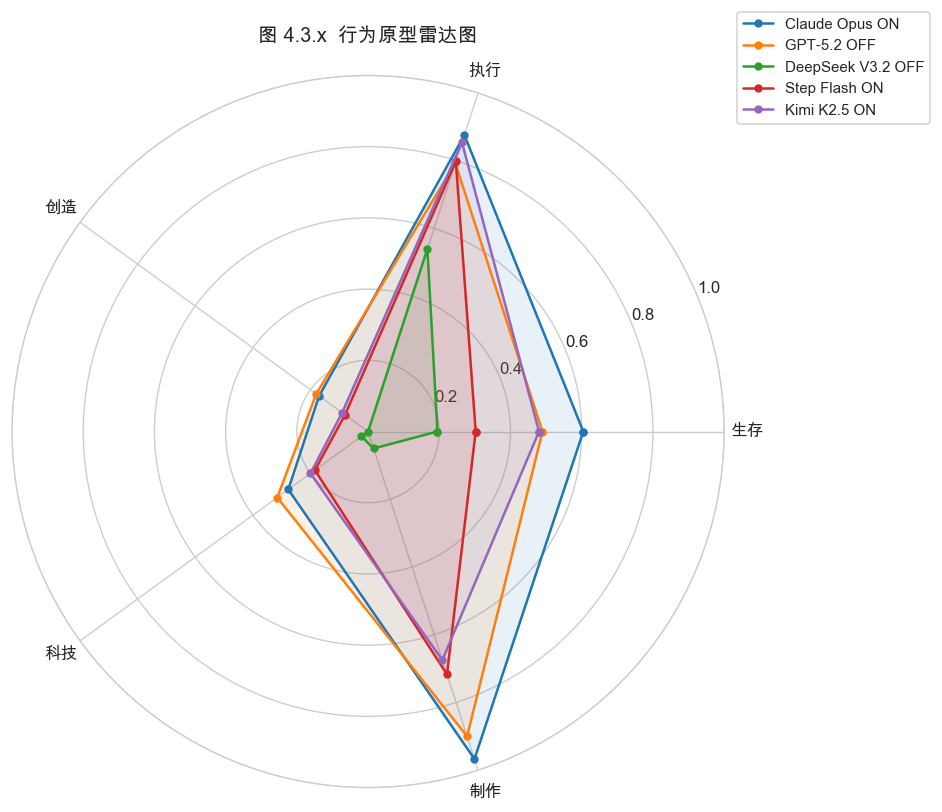

In [24]:
# ── 行为原型雷达图 ──

# 选择代表性模型
radar_models = [
    ('claude_opus_on', 'Claude Opus ON'),
    ('gpt52_off', 'GPT-5.2 OFF'),
    ('deepseek_v32_off', 'DeepSeek V3.2 OFF'),
    ('step_35_flash_on', 'Step Flash ON'),
    ('kimi_25_on', 'Kimi K2.5 ON'),
]

# 5 个维度，归一化到 0-1
radar_dims = ['hours_survived', 'valid_rate', 'inventions', 'tech_points', 'craft_success_rate']
radar_labels = ['生存', '执行', '创造', '科技', '制作']

# 归一化
norm_vals = {}
for col in radar_dims:
    vmin, vmax = df[col].min(), df[col].max()
    norm_vals[col] = (vmin, vmax)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2 * np.pi, len(radar_dims), endpoint=False).tolist()
angles += angles[:1]

radar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, (tag, name) in enumerate(radar_models):
    sub = df[df['player_tag'] == tag]
    if len(sub) == 0:
        continue
    values = []
    for col in radar_dims:
        vmin, vmax = norm_vals[col]
        rng = vmax - vmin if vmax != vmin else 1
        values.append((sub[col].mean() - vmin) / rng)
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=1.5, label=name, color=radar_colors[i], markersize=4)
    ax.fill(angles, values, alpha=0.1, color=radar_colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax.set_title('图 4.3.x  行为原型雷达图', pad=20)
plt.tight_layout()
fig.savefig(FIGURES / 'fig_4_3_x_radar.png', bbox_inches='tight')
plt.show()

In [25]:
print(f'\n已生成 {len(list(FIGURES.glob("*.png")))} 张图表到 {FIGURES}/')
for f in sorted(FIGURES.glob('*.png')):
    print(f'  {f.name}')


已生成 21 张图表到 /Users/zhihu/code/cli_sandbox/figures/
  fig_4_1_1_survival_boxplot.png
  fig_4_1_2_correlation_scatter.png
  fig_4_2_1_craft_success.png
  fig_4_2_2_inventions.png
  fig_4_2_3_thinking_delta.png
  fig_4_3_1_phase_strategy.png
  fig_4_3_2_human_likeness.png
  fig_4_3_3_notebook_usage.png
  fig_4_3_x_radar.png
  fig_4_4_1_inventions_survival.png
  fig_4_4_3_execution_vs_creation.png
  fig_4_5_1_cost_performance.png
  fig_4_6_1_qwen_failure_modes.png
  fig_4_6_2_qwen_degradation.png
  fig_A_1_entropy_reduction.png
  fig_BE_1_hallucination_leak.png
  fig_C_1_context_fatigue.png
  fig_D_1_thinking_efficiency.png
  fig_P1_1_distribution.png
  fig_P1_2_bootstrap.png
  fig_P1_3_seed42_ranking.png


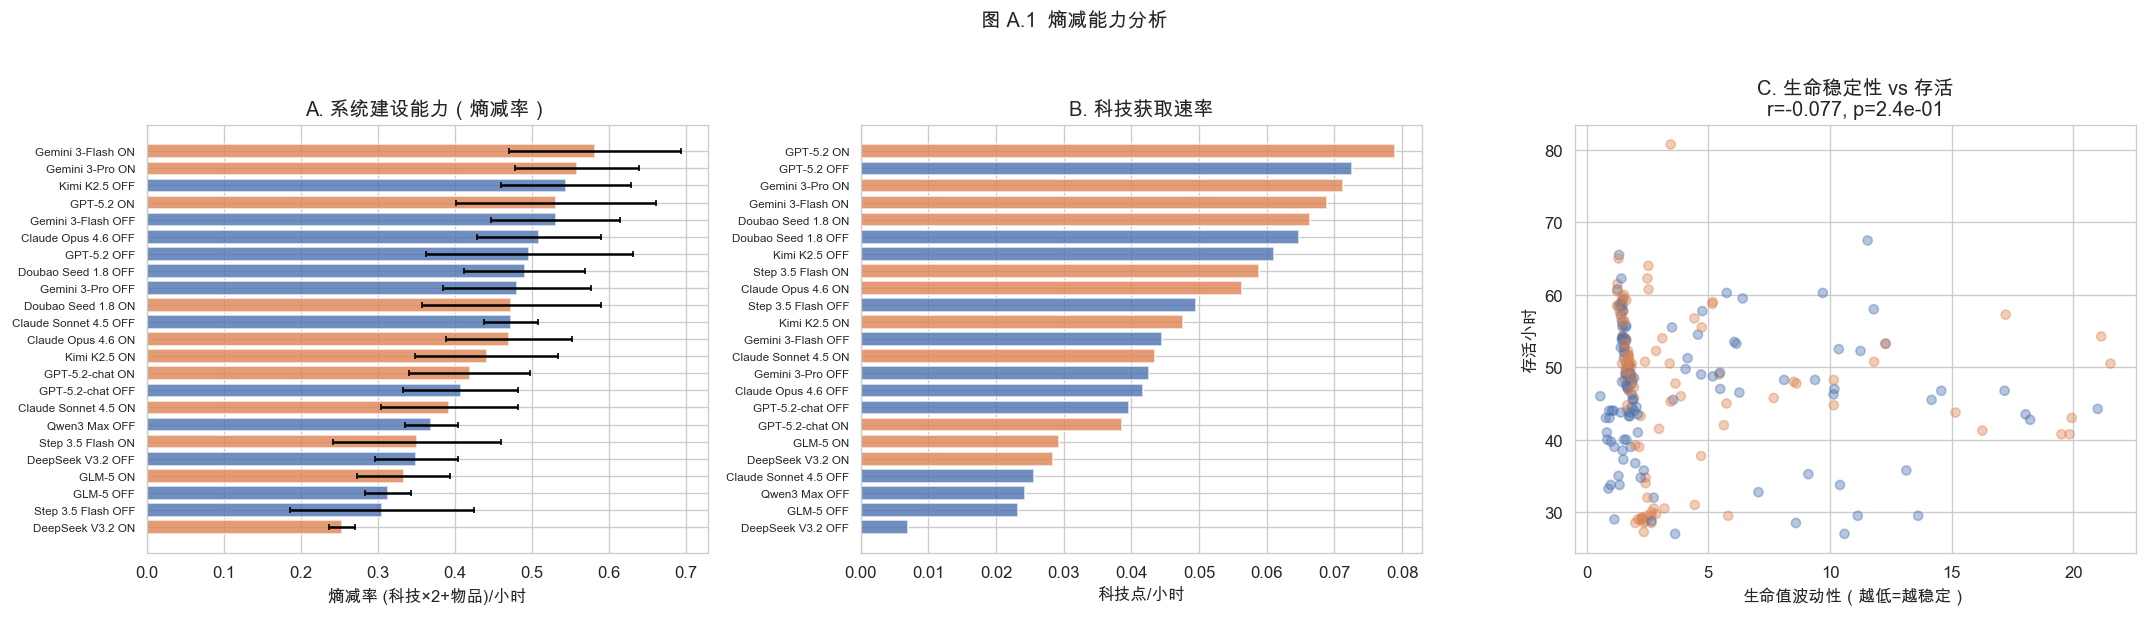

In [26]:
# ── 图 A.1：熵减能力 —— 科技点 & 物品累积随时间变化 ──

def calculate_entropy_reduction(ticks_by_run):
    """计算每个 run 的熵减指标"""
    results = []
    for run_id, run_ticks in ticks_by_run.items():
        if not run_ticks:
            continue
        
        # 逐 tick 追踪
        tech_timeline = []
        items_timeline = []
        health_stability = []  # 生命值变化的绝对值（越小=越稳定）
        
        cumulative_items = 0
        prev_health = None
        
        for t in run_ticks:
            tick_num = t.get('tick', 0)
            if tick_num <= 0:
                continue
            tech_timeline.append((tick_num, t.get('tech_points', 0)))
            cumulative_items += len(t.get('items_gained', []))
            items_timeline.append((tick_num, cumulative_items))
            
            health = t.get('status_after', {}).get('health', 100)
            if prev_health is not None:
                health_stability.append(abs(health - prev_health))
            prev_health = health
        
        if len(tech_timeline) < 2:
            continue
        
        total_ticks = tech_timeline[-1][0]
        final_tech = tech_timeline[-1][1]
        final_items = items_timeline[-1][1] if items_timeline else 0
        hours = sum(t.get('hours_elapsed', 0) for t in run_ticks)
        
        # 熵减率 = (科技点×2 + 物品数) / 存活小时
        # 科技点权重更高因为代表"秩序建设"
        entropy_reduction = (final_tech * 2 + final_items) / max(hours, 1)
        
        # 生命值稳定性（越低=越稳定=越好的危机管理）
        avg_health_volatility = np.mean(health_stability) if health_stability else 0
        
        results.append({
            'run_id': run_id,
            'entropy_reduction_rate': entropy_reduction,
            'tech_per_hour': final_tech / max(hours, 1),
            'items_per_hour': final_items / max(hours, 1),
            'health_volatility': avg_health_volatility,
            'final_tech': final_tech,
            'hours': hours,
        })
    return results

# 计算所有配置的熵减能力
entropy_data = []
for tag in sorted(all_ticks.keys()):
    if tag == 'qwen3_max_on':
        continue
    info = TAG_MAP.get(tag)
    if not info:
        continue
    model, thinking = info
    
    by_run = defaultdict(list)
    for t in all_ticks[tag]:
        by_run[t['run_id']].append(t)
    
    run_results = calculate_entropy_reduction(by_run)
    for r in run_results:
        r['model'] = model
        r['thinking'] = thinking
        r['label'] = f'{model} {thinking.upper()}'
        entropy_data.append(r)

ent_df = pd.DataFrame(entropy_data)

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A: 熵减率排名
ent_agg = ent_df.groupby('label').agg(
    er_mean=('entropy_reduction_rate', 'mean'),
    er_std=('entropy_reduction_rate', 'std'),
).sort_values('er_mean', ascending=True)
colors = [PALETTE_THINK['on'] if 'ON' in l else PALETTE_THINK['off'] for l in ent_agg.index]
axes[0].barh(range(len(ent_agg)), ent_agg['er_mean'], xerr=ent_agg['er_std'],
             color=colors, alpha=0.8, capsize=2)
axes[0].set_yticks(range(len(ent_agg)))
axes[0].set_yticklabels(ent_agg.index, fontsize=7)
axes[0].set_xlabel('熵减率 (科技×2+物品)/小时')
axes[0].set_title('A. 系统建设能力（熵减率）')

# B: 科技获取速率
tech_agg = ent_df.groupby('label')['tech_per_hour'].mean().sort_values()
colors2 = [PALETTE_THINK['on'] if 'ON' in l else PALETTE_THINK['off'] for l in tech_agg.index]
axes[1].barh(range(len(tech_agg)), tech_agg.values, color=colors2, alpha=0.8)
axes[1].set_yticks(range(len(tech_agg)))
axes[1].set_yticklabels(tech_agg.index, fontsize=7)
axes[1].set_xlabel('科技点/小时')
axes[1].set_title('B. 科技获取速率')

# C: 生命值波动性 vs 存活时间
axes[2].scatter(ent_df['health_volatility'], ent_df['hours'],
                c=[PALETTE_THINK[t] for t in ent_df['thinking']], alpha=0.4, s=30)
r, p = stats.pearsonr(ent_df['health_volatility'], ent_df['hours'])
axes[2].set_xlabel('生命值波动性（越低=越稳定）')
axes[2].set_ylabel('存活小时')
axes[2].set_title(f'C. 生命稳定性 vs 存活\nr={r:.3f}, p={p:.1e}')

plt.suptitle('图 A.1  熵减能力分析', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES / 'fig_A_1_entropy_reduction.png', bbox_inches='tight')
plt.show()

---
## 补充分析 C：上下文疲劳测试

随着游戏进行 Context 越来越长，模型的指令遵循能力是否下降？
区分"能力不足"和"注意力衰减"。

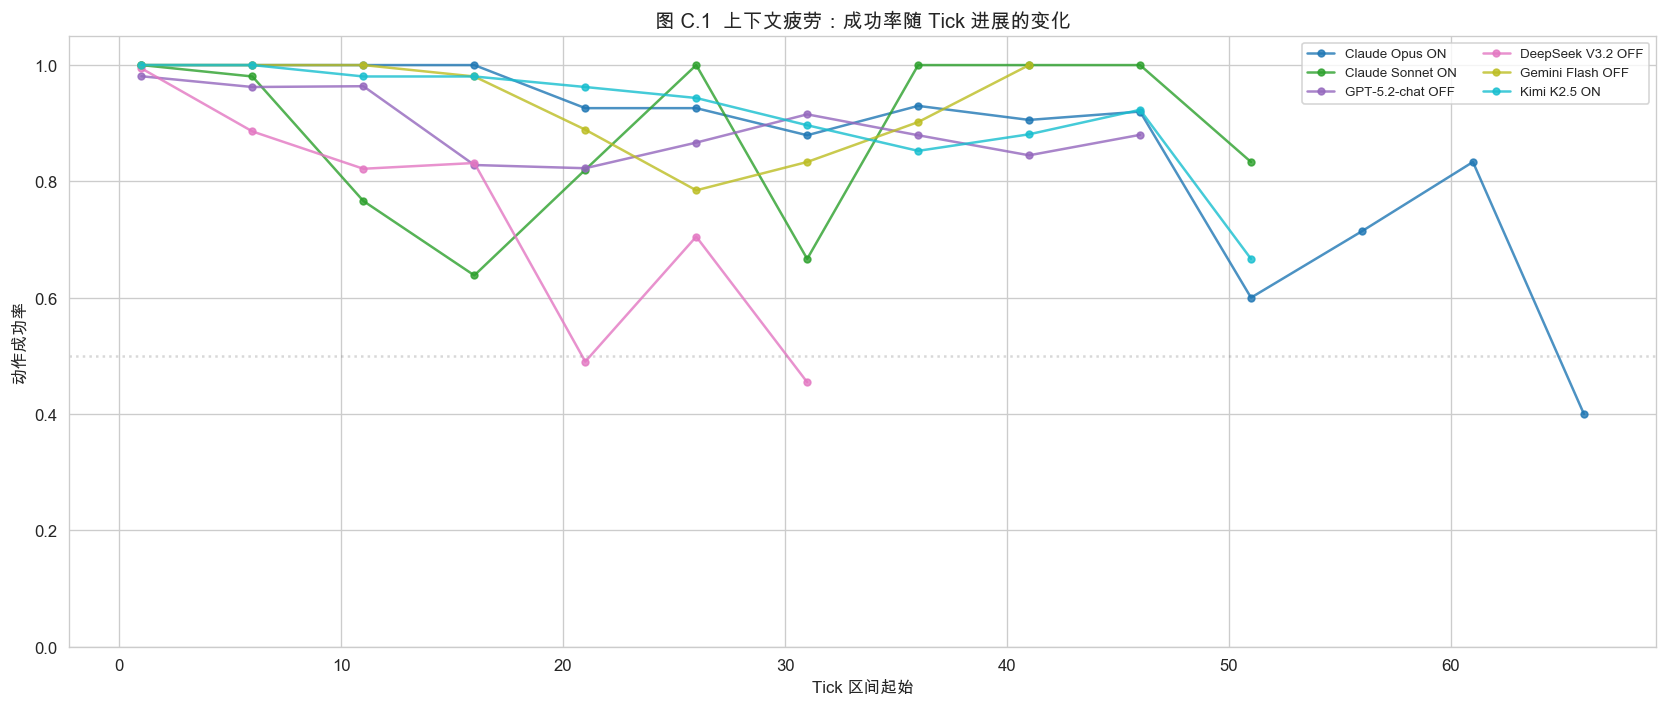


上下文疲劳统计（前10 vs 后10 tick 成功率）：
| 模型                  | 前10成功率   | 后10成功率   | Delta   | 显著性   |
|:----------------------|:-------------|:-------------|:--------|:---------|
| Claude Opus 4.6 OFF   | 81.0%        | 81.0%        | +0.0%   | ns       |
| Claude Opus 4.6 ON    | 100.0%       | 79.0%        | -21.0%  | *        |
| Claude Sonnet 4.5 OFF | 92.0%        | 88.0%        | -4.0%   | ns       |
| Claude Sonnet 4.5 ON  | 100.0%       | 71.0%        | -29.0%  | **       |
| DeepSeek V3.2 OFF     | 99.0%        | 44.0%        | -55.0%  | ***      |
| DeepSeek V3.2 ON      | 93.0%        | 85.0%        | -8.0%   | ns       |
| Doubao Seed 1.8 OFF   | 100.0%       | 90.0%        | -10.0%  | **       |
| Doubao Seed 1.8 ON    | 99.0%        | 91.0%        | -8.0%   | *        |
| Gemini 3-Flash ON     | 100.0%       | 89.0%        | -11.0%  | **       |
| Gemini 3-Flash OFF    | 100.0%       | 89.0%        | -11.0%  | ***      |
| Gemini 3-Pro ON       | 100.0%       | 66.0%        | -3

In [27]:
# ── 图 C.1：上下文疲劳 —— 成功率随 tick 变化 ──

def success_by_tick_bucket(ticks_by_run, bucket_size=5):
    """计算每个 tick 区间的成功率"""
    buckets = defaultdict(lambda: {'success': 0, 'total': 0})
    for run_id, run_ticks in ticks_by_run.items():
        for t in run_ticks:
            tick_num = t.get('tick', 0)
            if tick_num <= 0:
                continue
            bucket = ((tick_num - 1) // bucket_size) * bucket_size + 1
            buckets[bucket]['total'] += 1
            if t.get('success', False):
                buckets[bucket]['success'] += 1
    result = {}
    for b, counts in sorted(buckets.items()):
        if counts['total'] >= 3:  # 至少 3 个样本
            result[b] = counts['success'] / counts['total']
    return result

# 选择有代表性的模型
fatigue_tags = [
    ('claude_opus_on', 'Claude Opus ON'),
    ('claude_sonnet_on', 'Claude Sonnet ON'),
    ('gpt52_chat_off', 'GPT-5.2-chat OFF'),
    ('deepseek_v32_off', 'DeepSeek V3.2 OFF'),
    ('gemini_3_flash_off', 'Gemini Flash OFF'),
    ('kimi_25_on', 'Kimi K2.5 ON'),
]

fig, ax = plt.subplots(figsize=(14, 6))
fatigue_colors = plt.cm.tab10(np.linspace(0, 1, len(fatigue_tags)))

for i, (tag, name) in enumerate(fatigue_tags):
    if tag not in all_ticks:
        continue
    by_run = defaultdict(list)
    for t in all_ticks[tag]:
        by_run[t['run_id']].append(t)
    
    rates = success_by_tick_bucket(by_run, bucket_size=5)
    if rates:
        ticks_x = sorted(rates.keys())
        vals_y = [rates[b] for b in ticks_x]
        ax.plot(ticks_x, vals_y, 'o-', label=name, color=fatigue_colors[i], 
                markersize=4, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Tick 区间起始')
ax.set_ylabel('动作成功率')
ax.set_title('图 C.1  上下文疲劳：成功率随 Tick 进展的变化')
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / 'fig_C_1_context_fatigue.png', bbox_inches='tight')
plt.show()

# 全模型的前10 tick vs 后10 tick 成功率对比
print('\n上下文疲劳统计（前10 vs 后10 tick 成功率）：')
fatigue_summary = []
for tag in sorted(all_ticks.keys()):
    if tag == 'qwen3_max_on':
        continue
    info = TAG_MAP.get(tag)
    if not info:
        continue
    model, thinking = info
    
    by_run = defaultdict(list)
    for t in all_ticks[tag]:
        by_run[t['run_id']].append(t)
    
    early_rates, late_rates = [], []
    for run_id, run_ticks in by_run.items():
        valid_ticks = [t for t in run_ticks if t.get('tick', 0) > 0]
        if len(valid_ticks) < 10:
            continue
        early = valid_ticks[:10]
        late = valid_ticks[-10:]
        early_rate = sum(1 for t in early if t.get('success')) / len(early)
        late_rate = sum(1 for t in late if t.get('success')) / len(late)
        early_rates.append(early_rate)
        late_rates.append(late_rate)
    
    if early_rates:
        delta = np.mean(late_rates) - np.mean(early_rates)
        if len(early_rates) >= 3:
            t_stat, p_val = stats.ttest_rel(late_rates, early_rates)
        else:
            p_val = 1.0
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        fatigue_summary.append({
            '模型': f'{model} {thinking.upper()}',
            '前10成功率': f'{np.mean(early_rates):.1%}',
            '后10成功率': f'{np.mean(late_rates):.1%}',
            'Delta': f'{delta:+.1%}',
            '显著性': sig,
        })

print(pd.DataFrame(fatigue_summary).to_markdown(index=False))

---
## 补充分析 D：思维 Token 效率（成本-智能转化率）

思维模式带来了巨大的 token 开销（output tokens 增长 10-60x），
但这些"思考"是否都转化为了有效行动？
计算 `有效动作数 / 输出 token 数` 识别 "过度思考者"。

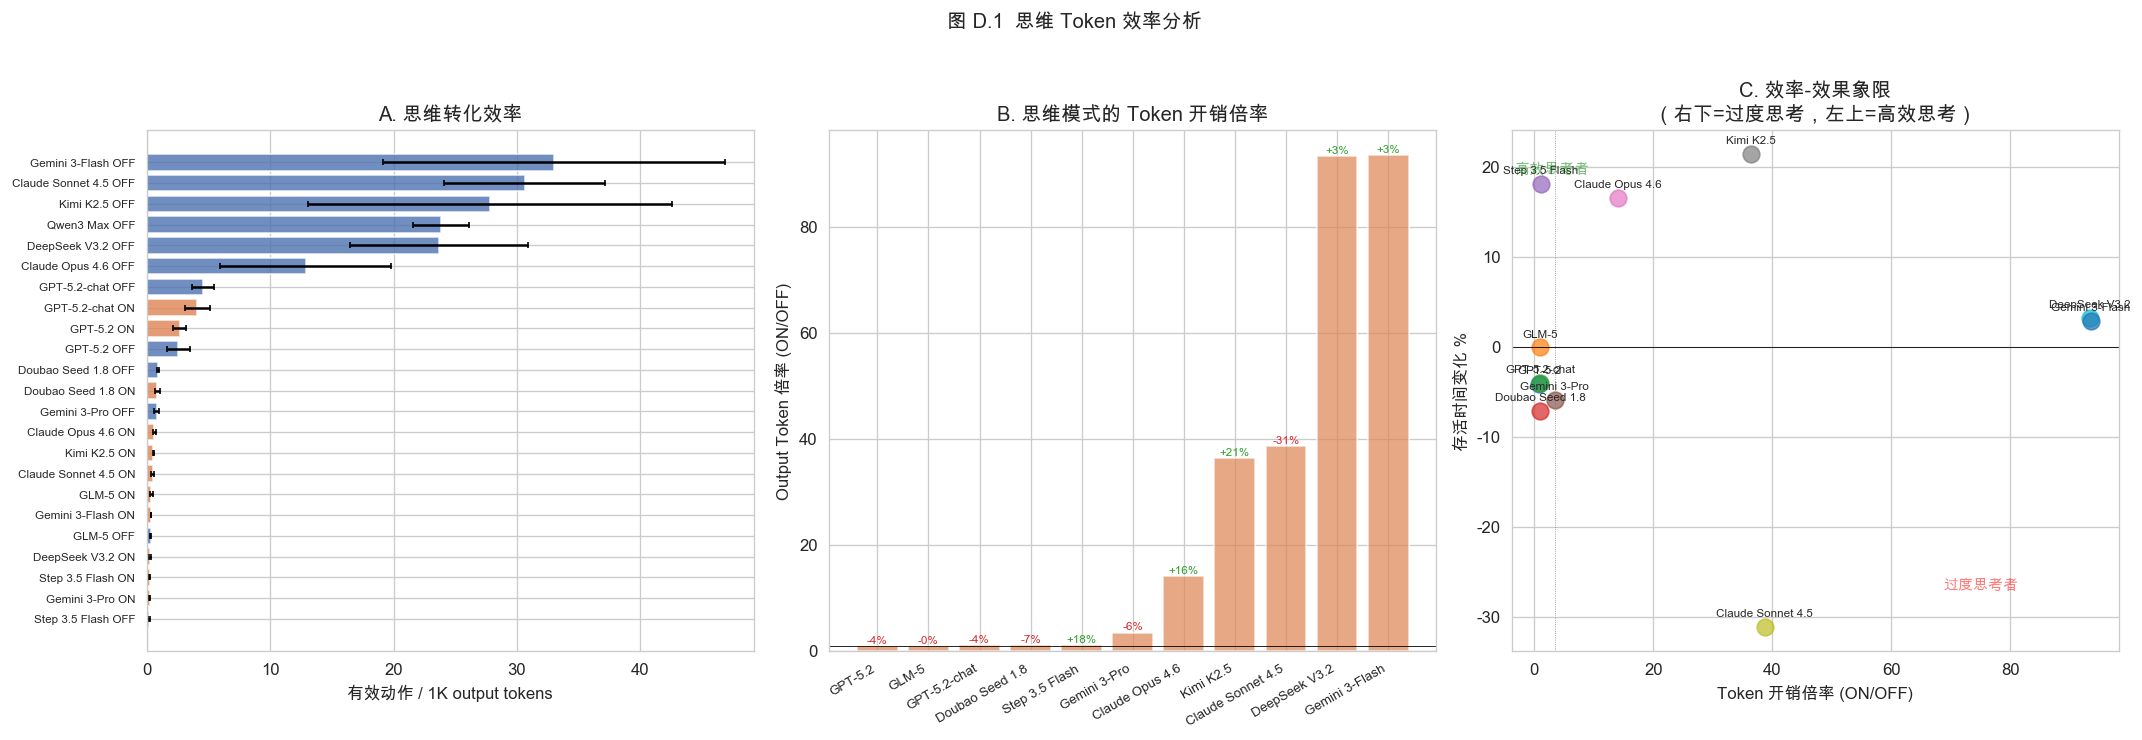


思维 Token 效率汇总：
| model             |    token_multiplier |   hours_delta_pct |   ROI |
|:------------------|--------------------:|------------------:|------:|
| Step 3.5 Flash    |  1.0829245455692316 |              18.1 |  16.7 |
| Claude Opus 4.6   | 14.069727190307425  |              16.5 |   1.2 |
| Kimi K2.5         | 36.415689608878544  |              21.4 |   0.6 |
| DeepSeek V3.2     | 93.3268809001621    |               3.1 |   0.0 |
| Gemini 3-Flash    | 93.56164175707458   |               2.9 |   0.0 |
| GLM-5             |  0.9308738185077017 |              -0.1 |  -0.1 |
| Claude Sonnet 4.5 | 38.683382947866576  |             -31.2 |  -0.8 |
| Gemini 3-Pro      |  3.435926203926836  |              -5.9 |  -1.7 |
| GPT-5.2-chat      |  1.0147511274075947 |              -4.0 |  -4.0 |
| GPT-5.2           |  0.8620030393646748 |              -4.1 |  -4.8 |
| Doubao Seed 1.8   |  1.0222810529541795 |              -7.2 |  -7.0 |


In [28]:
# ── 图 D.1：思维 Token 效率分析 ──

# 计算关键指标
df['valid_actions'] = df['actions_taken'] * df['valid_rate'] / 100
df['valid_per_1k_output'] = df['valid_actions'] / (df['total_output_tokens'] / 1000)
df['hours_per_1k_total'] = df['hours_survived'] / (df['total_tokens'] / 1000)
df['thinking_overhead'] = df['total_output_tokens'] / df['actions_taken']  # 每动作平均输出 token

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Panel A：有效动作 / 1K output tokens（越高=思维越高效）──
eff_agg = df.groupby('label').agg(
    vpo_mean=('valid_per_1k_output', 'mean'),
    vpo_std=('valid_per_1k_output', 'std'),
    thinking=('thinking', 'first'),
).sort_values('vpo_mean', ascending=True)

colors = [PALETTE_THINK[r['thinking']] for _, r in eff_agg.iterrows()]
axes[0].barh(range(len(eff_agg)), eff_agg['vpo_mean'], xerr=eff_agg['vpo_std'],
             color=colors, alpha=0.8, capsize=2)
axes[0].set_yticks(range(len(eff_agg)))
axes[0].set_yticklabels(eff_agg.index, fontsize=7)
axes[0].set_xlabel('有效动作 / 1K output tokens')
axes[0].set_title('A. 思维转化效率')

# ── Panel B：ON vs OFF 的 token 开销对比 ──
overhead_data = []
for m in paired_models:
    off_tok = df[(df['model']==m) & (df['thinking']=='off')]['total_output_tokens'].mean()
    on_tok = df[(df['model']==m) & (df['thinking']=='on')]['total_output_tokens'].mean()
    off_hours = df[(df['model']==m) & (df['thinking']=='off')]['hours_survived'].mean()
    on_hours = df[(df['model']==m) & (df['thinking']=='on')]['hours_survived'].mean()
    overhead_data.append({
        'model': m,
        'token_multiplier': on_tok / max(off_tok, 1),
        'hours_delta_pct': (on_hours - off_hours) / max(off_hours, 1) * 100,
    })
oh_df = pd.DataFrame(overhead_data).sort_values('token_multiplier', ascending=True)

ax_b = axes[1]
x = np.arange(len(oh_df))
bars = ax_b.bar(x, oh_df['token_multiplier'], color='#DD8452', alpha=0.7)
ax_b.set_xticks(x)
ax_b.set_xticklabels(oh_df['model'], rotation=30, ha='right', fontsize=8)
ax_b.set_ylabel('Output Token 倍率 (ON/OFF)')
ax_b.axhline(1, color='k', linewidth=0.5)
ax_b.set_title('B. 思维模式的 Token 开销倍率')

# 在柱子上标注存活时间变化
for i, (_, row) in enumerate(oh_df.iterrows()):
    color = '#2ca02c' if row['hours_delta_pct'] > 0 else '#d62728'
    ax_b.text(i, row['token_multiplier'] + 0.5, f"{row['hours_delta_pct']:+.0f}%",
              ha='center', fontsize=7, color=color, fontweight='bold')

# ── Panel C：效率-效果象限图 ──
ax_c = axes[2]
for _, row in oh_df.iterrows():
    ax_c.scatter(row['token_multiplier'], row['hours_delta_pct'], s=100, alpha=0.7)
    ax_c.annotate(row['model'], (row['token_multiplier'], row['hours_delta_pct']),
                  fontsize=7, ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

ax_c.axhline(0, color='k', linewidth=0.5, linestyle='-')
ax_c.axvline(oh_df['token_multiplier'].median(), color='gray', linewidth=0.5, linestyle=':')
ax_c.set_xlabel('Token 开销倍率 (ON/OFF)')
ax_c.set_ylabel('存活时间变化 %')
ax_c.set_title('C. 效率-效果象限\n（右下=过度思考，左上=高效思考）')

# 象限标注
xlim = ax_c.get_xlim()
ylim = ax_c.get_ylim()
med_x = oh_df['token_multiplier'].median()
ax_c.text(xlim[0] + 0.5, ylim[1] * 0.8, '高效思考者', fontsize=9, color='green', alpha=0.5)
ax_c.text(xlim[1] * 0.7, ylim[0] * 0.8, '过度思考者', fontsize=9, color='red', alpha=0.5)

plt.suptitle('图 D.1  思维 Token 效率分析', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES / 'fig_D_1_thinking_efficiency.png', bbox_inches='tight')
plt.show()

# 汇总表
print('\n思维 Token 效率汇总：')
eff_summary = oh_df.copy()
eff_summary['ROI'] = eff_summary['hours_delta_pct'] / eff_summary['token_multiplier']
eff_summary = eff_summary.sort_values('ROI', ascending=False)
print(eff_summary[['model', 'token_multiplier', 'hours_delta_pct', 'ROI']].to_markdown(
    index=False, floatfmt=('.0f', '', '.1f', '.1f', '.2f')))

---
## 补充分析 B/E：幻觉行为对比 & Qwen 思维内容泄漏

- **B**: DeepSeek V3.2 OFF 的幻觉循环（反复尝试不存在的配方）vs ON 的行为修正，
  通过动作模式变化间接推断 CoT 的"现实锚定"效果。
- **E**: Qwen3 Max ON 的 `</think>` 标签泄漏深度分析，
  检查思维内容是否侵入了输出流。

/var/folders/1v/w400c0x556qgw30t7nnp9l4r0000gn/T/ipykernel_18515/211963806.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, labels=['OFF', 'ON'], patch_artist=True,
/var/folders/1v/w400c0x556qgw30t7nnp9l4r0000gn/T/ipykernel_18515/211963806.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(data_bp2, labels=['OFF', 'ON'], patch_artist=True,


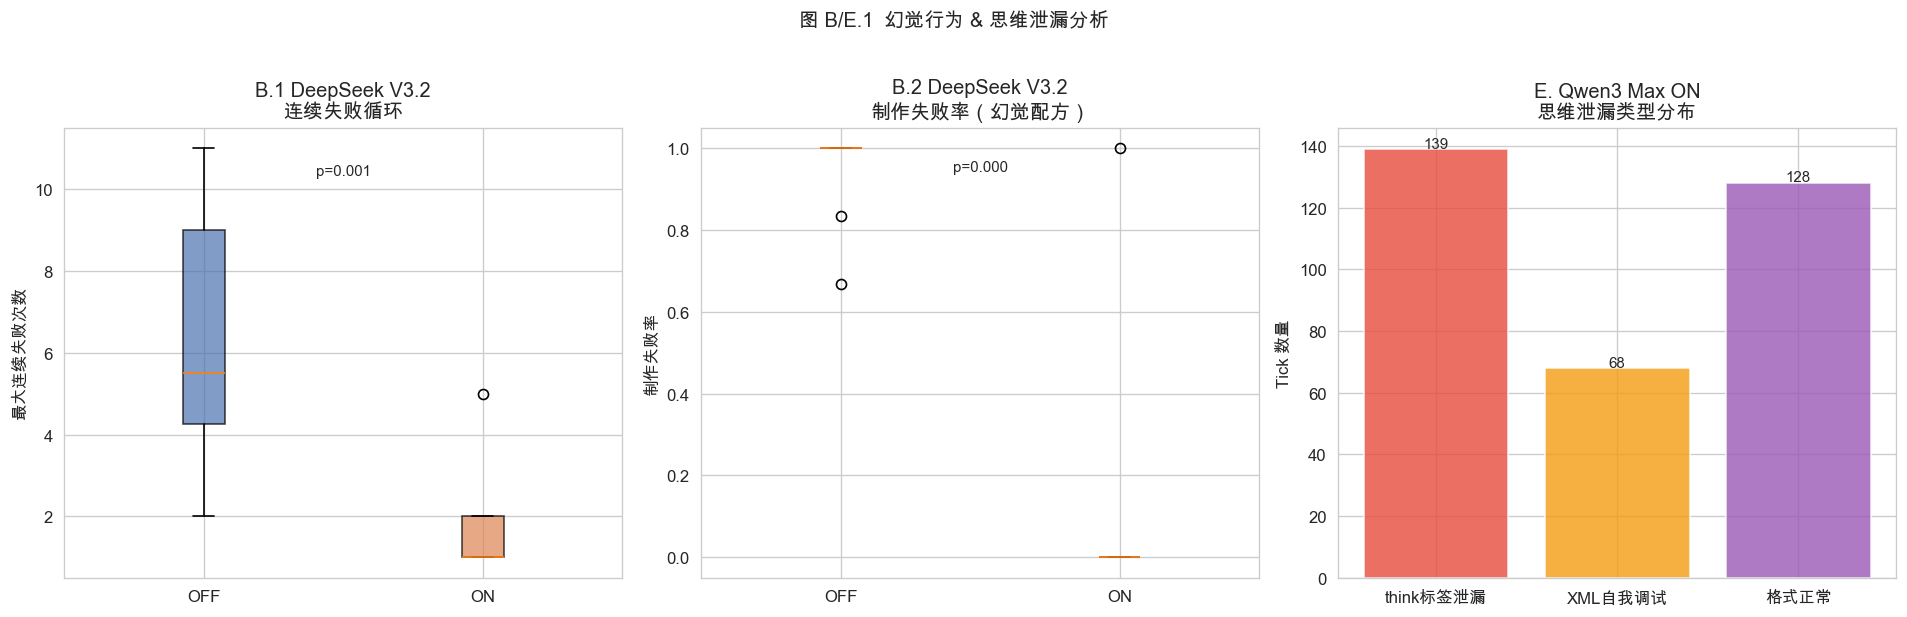


DeepSeek V3.2 幻觉行为对比：
  最大连续失败: OFF=6.20, ON=1.70, delta=-4.50
  制作失败率: OFF=0.95, ON=0.10, delta=-0.85
  重复动作数: OFF=18.00, ON=1.10, delta=-16.90

Qwen3 Max ON 泄漏示例（前3个含 </think> 的 tick）：
  Tick 0: <?xml version="1.0" encoding="UTF-8"?>
<root>
  <answer>
    首先，用户要求“仅输出一行指，不要解释”，但指令需要满足XML格式。题目要求使用特定动作格式：使用<action>和optional</<detal</detl>。动作名称为“采集”，参数为要采集的物资名称（如“导线”）。当前位置坠毁点有可采集资源：钛合金碎片4单位、合物板3单...
  Tick 0: 我们当前位于坠毁点，体力66，状态尚 可。已知配方需要特定属性材料，坠毁点资源（钛合金碎片、聚合物板、导线）属性不匹配切割工具（缺脆性）和绳索（缺坚韧）。为推进生存，需探索获取关键材 料。北侧山脊高地可能出现含[坚硬,脆性]的岩石（如黑曜石），是制作切割工具的优先目标。移动耗时1小时、体力-10，当前体力充足。无需先采集（避免体力浪费且资源可返回采集），直接移动探索更 高效。
严格按照XML指令格...
  Tick 0:  <action>移动</action>
<  /detail>东     <?  但注意 ： <detail> 标签必须正确。应为：

<action   >移动</action>
<detail>东/ ? ? 不，结束标签是 > /detail>

正确为：
       (action>移动 </action>
       <detail>东</detail>

但注意： 我们必须确保 标...


In [29]:
# ── 图 B/E.1：DeepSeek 幻觉行为对比 + Qwen 思维泄漏 ──

import re

# ═══ Part B: DeepSeek V3.2 OFF vs ON 行为对比 ═══

def analyze_hallucination_patterns(ticks):
    """分析幻觉行为模式：重复失败尝试、不存在配方等"""
    by_run = defaultdict(list)
    for t in ticks:
        by_run[t['run_id']].append(t)
    
    run_stats = []
    for run_id, run_ticks in by_run.items():
        consecutive_fails = 0
        max_consecutive = 0
        failed_crafts = 0
        total_crafts = 0
        repeated_actions = []
        prev_raw = ''
        
        for t in run_ticks:
            if t.get('tick', 0) <= 0:
                continue
            
            is_craft = t.get('action_type') in ('craft', 'combine')
            success = t.get('success', False)
            raw = (t.get('llm_raw_output', '') or '')[:200]
            
            if is_craft:
                total_crafts += 1
                if not success:
                    failed_crafts += 1
            
            if not success:
                consecutive_fails += 1
                max_consecutive = max(max_consecutive, consecutive_fails)
            else:
                consecutive_fails = 0
            
            # 重复检测
            if raw and raw == prev_raw:
                repeated_actions.append(raw[:50])
            prev_raw = raw
        
        run_stats.append({
            'run_id': run_id,
            'max_consecutive_fails': max_consecutive,
            'failed_crafts': failed_crafts,
            'total_crafts': total_crafts,
            'craft_fail_rate': failed_crafts / max(total_crafts, 1),
            'repeat_count': len(repeated_actions),
            'total_ticks': len([t for t in run_ticks if t.get('tick', 0) > 0]),
        })
    return pd.DataFrame(run_stats)

ds_off = analyze_hallucination_patterns(all_ticks.get('deepseek_v32_off', []))
ds_on = analyze_hallucination_patterns(all_ticks.get('deepseek_v32_on', []))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# B.1: 最大连续失败次数
ax = axes[0]
data_bp = [ds_off['max_consecutive_fails'].values, ds_on['max_consecutive_fails'].values]
bp = ax.boxplot(data_bp, labels=['OFF', 'ON'], patch_artist=True,
                boxprops=dict(alpha=0.7))
bp['boxes'][0].set_facecolor(PALETTE_THINK['off'])
bp['boxes'][1].set_facecolor(PALETTE_THINK['on'])
ax.set_ylabel('最大连续失败次数')
ax.set_title('B.1 DeepSeek V3.2\n连续失败循环')
if len(ds_off) > 1 and len(ds_on) > 1:
    _, p = stats.mannwhitneyu(ds_off['max_consecutive_fails'], ds_on['max_consecutive_fails'])
    ax.text(1.5, ax.get_ylim()[1]*0.9, f'p={p:.3f}', ha='center', fontsize=9)

# B.2: 制作失败率
ax = axes[1]
data_bp2 = [ds_off['craft_fail_rate'].values, ds_on['craft_fail_rate'].values]
bp2 = ax.boxplot(data_bp2, labels=['OFF', 'ON'], patch_artist=True,
                 boxprops=dict(alpha=0.7))
bp2['boxes'][0].set_facecolor(PALETTE_THINK['off'])
bp2['boxes'][1].set_facecolor(PALETTE_THINK['on'])
ax.set_ylabel('制作失败率')
ax.set_title('B.2 DeepSeek V3.2\n制作失败率（幻觉配方）')
if len(ds_off) > 1 and len(ds_on) > 1:
    _, p = stats.mannwhitneyu(ds_off['craft_fail_rate'], ds_on['craft_fail_rate'])
    ax.text(1.5, ax.get_ylim()[1]*0.9, f'p={p:.3f}', ha='center', fontsize=9)

# ═══ Part E: Qwen3 Max ON 思维泄漏分析 ═══
ax = axes[2]
qwen_ticks = all_ticks.get('qwen3_max_on', [])
if qwen_ticks:
    leak_categories = {
        'think标签泄漏': 0,
        'XML自我调试': 0,
        '推理文本入侵': 0,
        '格式正常': 0,
    }
    
    for t in qwen_ticks:
        raw = t.get('llm_raw_output', '') or ''
        if not raw.strip():
            continue
        
        has_think_tag = '</think>' in raw or '<think>' in raw
        has_xml_debug = bool(re.search(r'标签|格式|注意.*<|正确.*>', raw))
        has_reasoning = bool(re.search(r'我需要|让我|分析|首先|应该|思考', raw)) and len(raw) > 150
        has_valid_action = bool(re.search(r'<action>\w+</action>', raw))
        
        if has_think_tag:
            leak_categories['think标签泄漏'] += 1
        elif has_xml_debug:
            leak_categories['XML自我调试'] += 1
        elif has_reasoning and not has_valid_action:
            leak_categories['推理文本入侵'] += 1
        elif has_valid_action:
            leak_categories['格式正常'] += 1
        # else: 其他类型已在 4.6 中分析
    
    cats = {k: v for k, v in leak_categories.items() if v > 0}
    if cats:
        colors_pie = ['#e74c3c', '#f39c12', '#9b59b6', '#2ecc71']
        ax.bar(cats.keys(), cats.values(), color=colors_pie[:len(cats)], alpha=0.8)
        ax.set_ylabel('Tick 数量')
        ax.set_title('E. Qwen3 Max ON\n思维泄漏类型分布')
        for i, (k, v) in enumerate(cats.items()):
            ax.text(i, v + 0.5, str(v), ha='center', fontsize=9)
else:
    ax.text(0.5, 0.5, '无 Qwen3 Max ON 数据', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('图 B/E.1  幻觉行为 & 思维泄漏分析', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES / 'fig_BE_1_hallucination_leak.png', bbox_inches='tight')
plt.show()

# ── DeepSeek 行为对比摘要 ──
print('\nDeepSeek V3.2 幻觉行为对比：')
compare_cols = ['max_consecutive_fails', 'craft_fail_rate', 'repeat_count']
compare_labels = ['最大连续失败', '制作失败率', '重复动作数']
for col, label in zip(compare_cols, compare_labels):
    off_val = ds_off[col].mean() if len(ds_off) else 0
    on_val = ds_on[col].mean() if len(ds_on) else 0
    print(f'  {label}: OFF={off_val:.2f}, ON={on_val:.2f}, delta={on_val-off_val:+.2f}')

# ── Qwen 泄漏示例 ──
if qwen_ticks:
    print('\nQwen3 Max ON 泄漏示例（前3个含 </think> 的 tick）：')
    count = 0
    for t in qwen_ticks:
        raw = t.get('llm_raw_output', '') or ''
        if '</think>' in raw and count < 3:
            print(f"  Tick {t.get('tick')}: {raw[:200]}...")
            count += 1

---
## Phase 1：大规模采样充分性验证

用 3 个便宜模型（Gemini 3 Flash OFF、Doubao v1.8 OFF）× 3 seeds × 100 轮 = 600 局，
验证 n=10 的采样充分性。核心问题：
1. n=10 的均值估计误差有多大？
2. 抽 10 次能否保持模型间排名？
3. 分布是正态还是偏态/双峰？
4. 回看 seed=42 的 24 模型排名，哪些模型对在 n=10 下无法区分？

In [30]:
# ── Phase 1 数据加载 ──
import json, glob, random
from pathlib import Path

PHASE1_SEEDS = [7, 233, 999]
PHASE1_MODELS = {
    'gemini_3_flash_off': 'Gemini Flash',
    'doubao_v18_off': 'Doubao v1.8',
}

def load_phase1_hours(seed, model_tag):
    files = sorted(glob.glob(f'eval_results/seed_{seed}/{model_tag}/run_*.jsonl'))
    hours = []
    for f in files:
        lines = [json.loads(l) for l in open(f) if l.strip()]
        final = [l for l in lines if l.get('type') == 'final_score']
        if final:
            hours.append(final[0]['scores']['hours_survived'])
    return hours

# 加载全部数据
phase1_data = {}
for tag, label in PHASE1_MODELS.items():
    for seed in PHASE1_SEEDS:
        key = (label, seed)
        h = load_phase1_hours(seed, tag)
        phase1_data[key] = h
        print(f'{label} seed={seed}: n={len(h)}, mean={np.mean(h):.1f}h, std={np.std(h):.1f}')

# 合并所有 seed
phase1_pooled = {}
for tag, label in PHASE1_MODELS.items():
    all_h = []
    for seed in PHASE1_SEEDS:
        all_h.extend(phase1_data[(label, seed)])
    phase1_pooled[label] = all_h
    print(f'{label} ALL: n={len(all_h)}, mean={np.mean(all_h):.1f}h, std={np.std(all_h):.1f}')

Gemini Flash seed=7: n=99, mean=35.4h, std=9.5


Gemini Flash seed=233: n=100, mean=36.5h, std=4.7
Gemini Flash seed=999: n=99, mean=42.3h, std=5.5


Doubao v1.8 seed=7: n=98, mean=40.3h, std=10.5
Doubao v1.8 seed=233: n=99, mean=44.3h, std=6.2
Doubao v1.8 seed=999: n=99, mean=43.3h, std=9.6
Gemini Flash ALL: n=298, mean=38.1h, std=7.5
Doubao v1.8 ALL: n=296, mean=42.6h, std=9.1


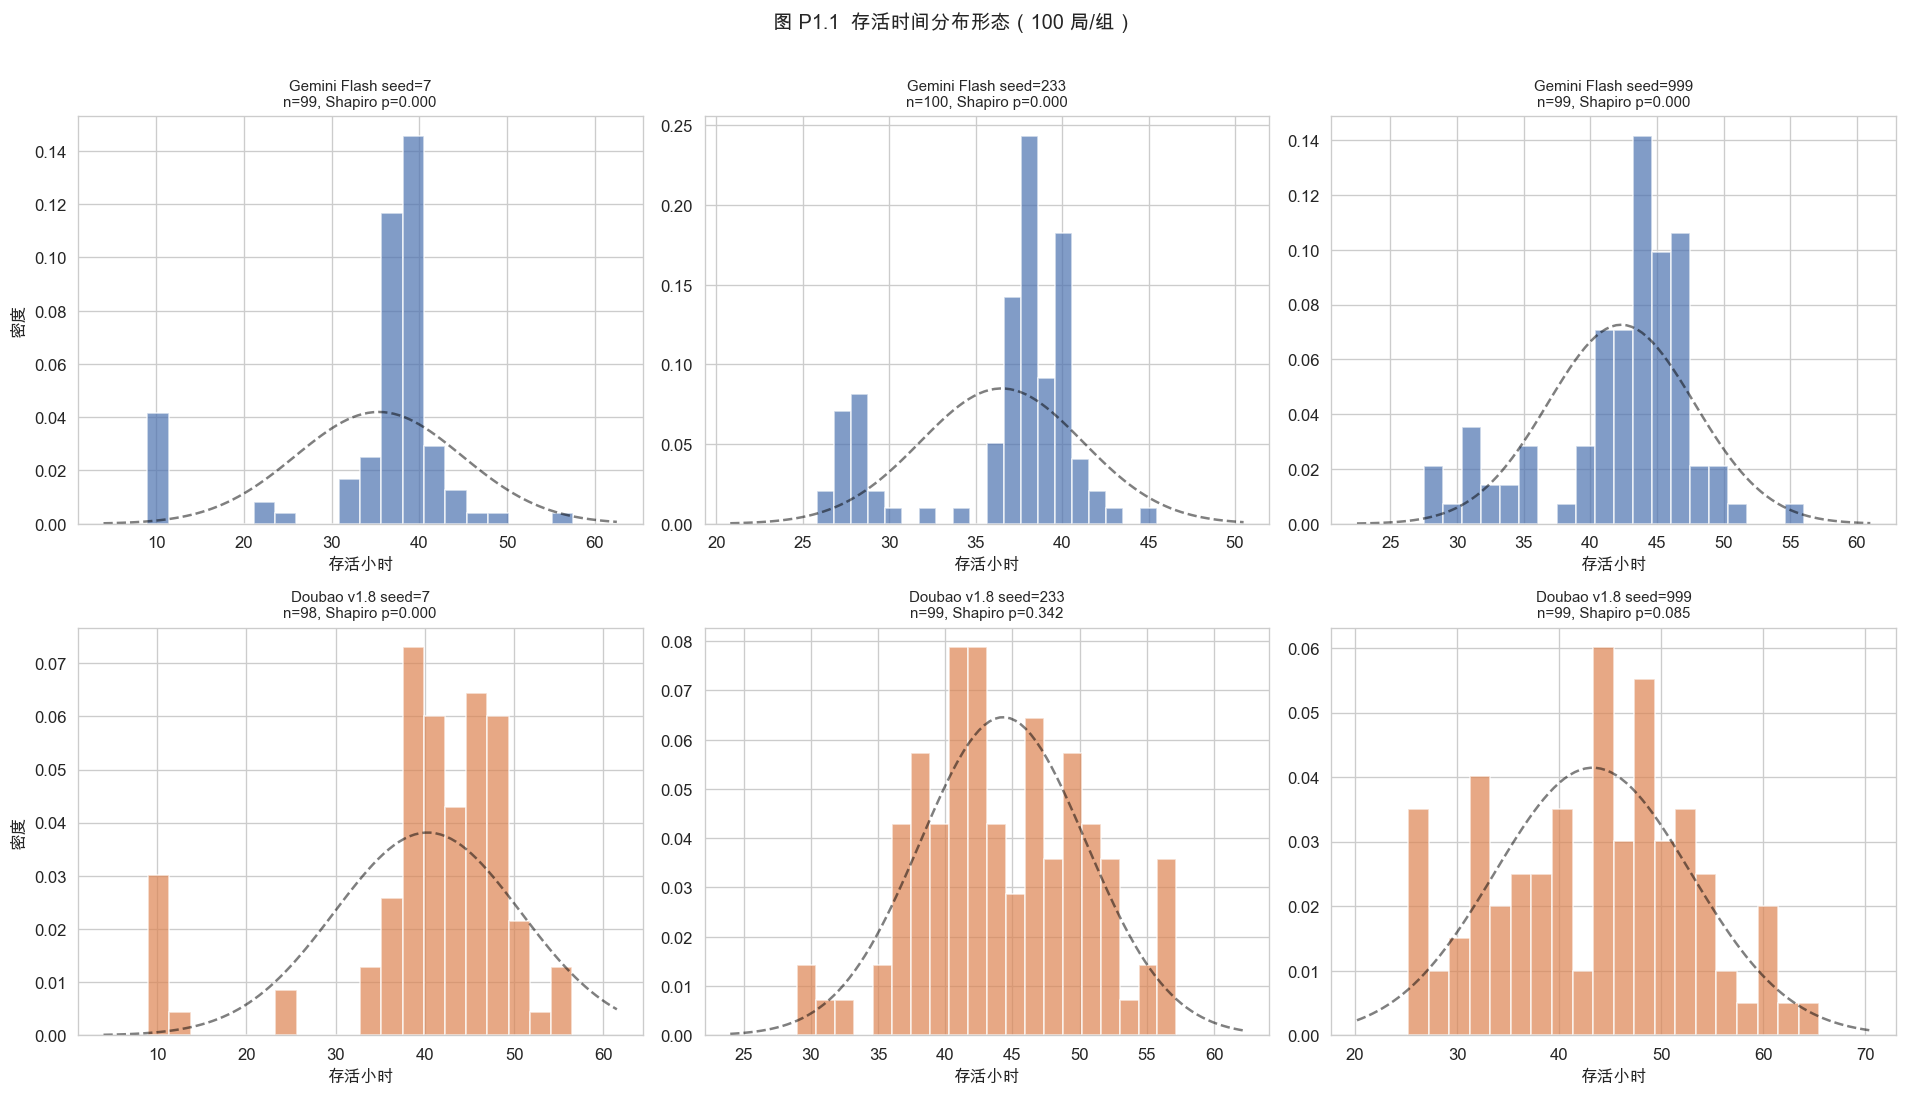

In [31]:
# ── 图 P1.1：分布形态检验 ──

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (label, color) in enumerate([
    ('Gemini Flash', '#4C72B0'), ('Doubao v1.8', '#DD8452')
]):
    for col, seed in enumerate(PHASE1_SEEDS):
        ax = axes[row][col]
        h = phase1_data[(label, seed)]
        if not h:
            continue
        ax.hist(h, bins=20, color=color, alpha=0.7, edgecolor='white', density=True)
        # 正态拟合
        mu, sigma = np.mean(h), np.std(h)
        x = np.linspace(min(h)-5, max(h)+5, 100)
        ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k--', alpha=0.5, label='正态拟合')
        # Shapiro-Wilk
        if len(h) > 8:
            sw_stat, sw_p = stats.shapiro(h[:500])  # shapiro max 5000
            ax.set_title(f'{label} seed={seed}\nn={len(h)}, Shapiro p={sw_p:.3f}', fontsize=9)
        ax.set_xlabel('存活小时')
        ax.set_ylabel('密度' if col == 0 else '')

plt.suptitle('图 P1.1  存活时间分布形态（100 局/组）', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES / 'fig_P1_1_distribution.png', bbox_inches='tight')
plt.show()

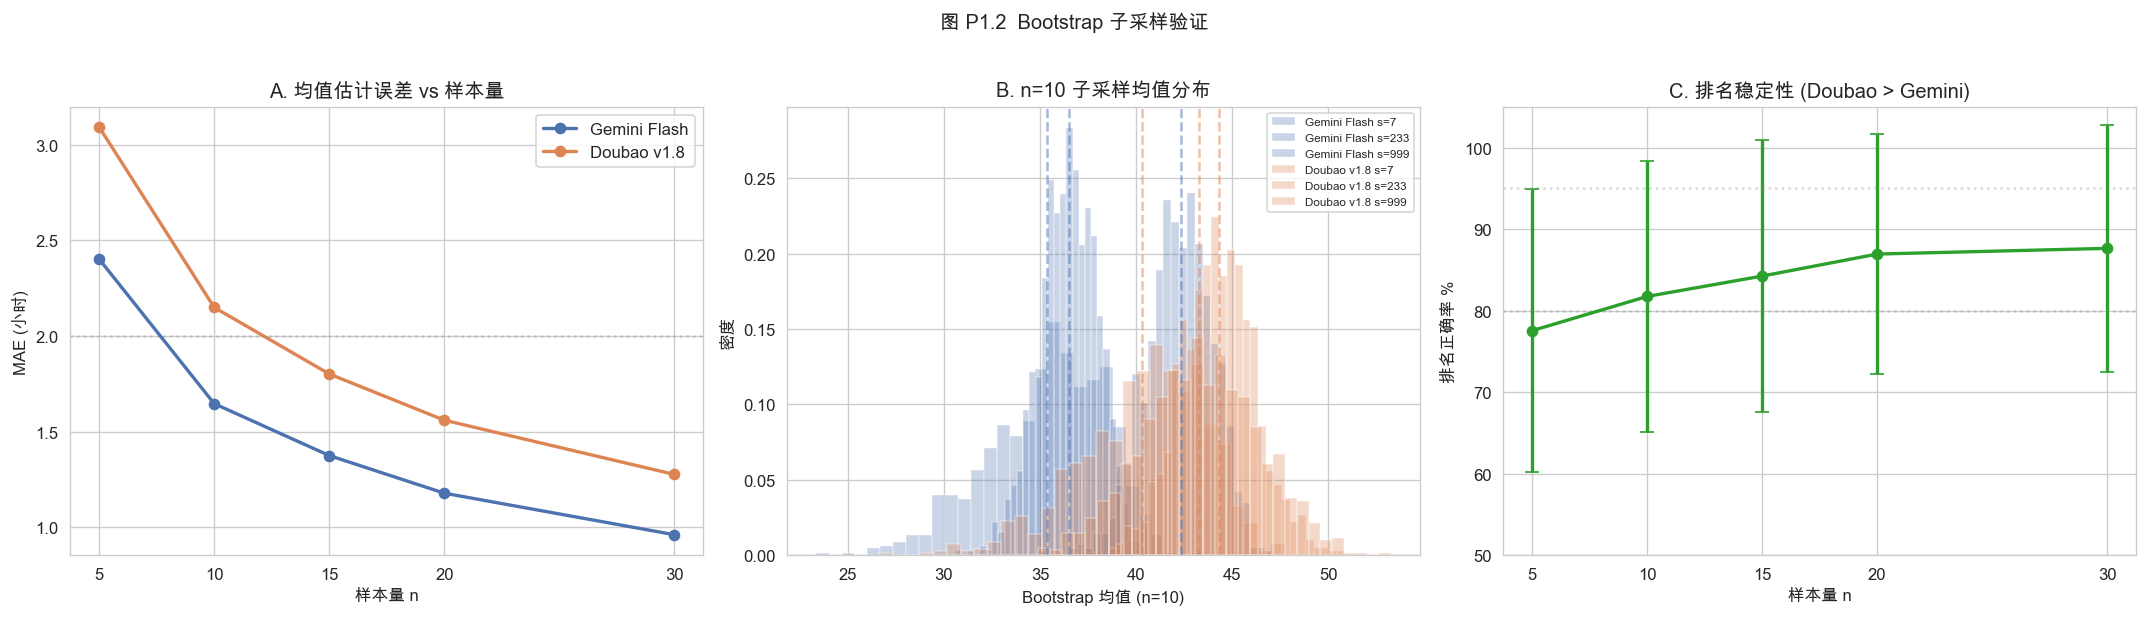


不同样本量的统计特性：
  n= 5: MAE=2.77h, 排名正确率=77.5%
  n=10: MAE=1.91h, 排名正确率=81.7%
  n=15: MAE=1.58h, 排名正确率=84.2%
  n=20: MAE=1.36h, 排名正确率=86.9%
  n=30: MAE=1.12h, 排名正确率=87.6%


In [32]:
# ── 图 P1.2：Bootstrap 子采样验证 ──

random.seed(42)
sample_sizes = [5, 10, 15, 20, 30]
N_BOOTSTRAP = 1000

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel A: 不同 n 的均值估计误差 (MAE) ──
ax = axes[0]
for label, color in [('Gemini Flash', '#4C72B0'), ('Doubao v1.8', '#DD8452')]:
    maes = []
    for n in sample_sizes:
        seed_maes = []
        for seed in PHASE1_SEEDS:
            h = phase1_data[(label, seed)]
            if not h: continue
            true_mean = np.mean(h)
            errors = [abs(np.mean(random.choices(h, k=n)) - true_mean) for _ in range(N_BOOTSTRAP)]
            seed_maes.append(np.mean(errors))
        maes.append(np.mean(seed_maes))
    ax.plot(sample_sizes, maes, 'o-', label=label, color=color, linewidth=2)
ax.set_xlabel('样本量 n')
ax.set_ylabel('MAE (小时)')
ax.set_title('A. 均值估计误差 vs 样本量')
ax.legend()
ax.axhline(2, color='gray', linestyle=':', alpha=0.3, label='MAE=2h')
ax.set_xticks(sample_sizes)

# ── Panel B: n=10 时均值的 bootstrap 分布 ──
ax = axes[1]
for label, color in [('Gemini Flash', '#4C72B0'), ('Doubao v1.8', '#DD8452')]:
    for seed in PHASE1_SEEDS:
        h = phase1_data[(label, seed)]
        if not h: continue
        sampled_means = [np.mean(random.choices(h, k=10)) for _ in range(N_BOOTSTRAP)]
        ax.hist(sampled_means, bins=30, alpha=0.3, color=color, density=True,
                label=f'{label} s={seed}')
        ax.axvline(np.mean(h), color=color, linestyle='--', alpha=0.5)
ax.set_xlabel('Bootstrap 均值 (n=10)')
ax.set_ylabel('密度')
ax.set_title('B. n=10 子采样均值分布')
ax.legend(fontsize=7)

# ── Panel C: 排名稳定性 ──
ax = axes[2]
rank_correct_by_n = {n: [] for n in sample_sizes}
for seed in PHASE1_SEEDS:
    g = phase1_data[('Gemini Flash', seed)]
    d = phase1_data[('Doubao v1.8', seed)]
    if not g or not d: continue
    true_rank = np.mean(d) > np.mean(g)  # True if Doubao > Gemini
    for n in sample_sizes:
        correct = sum(
            1 for _ in range(N_BOOTSTRAP)
            if (np.mean(random.choices(d, k=n)) > np.mean(random.choices(g, k=n))) == true_rank
        )
        rank_correct_by_n[n].append(correct / N_BOOTSTRAP * 100)

means_rc = [np.mean(rank_correct_by_n[n]) for n in sample_sizes]
stds_rc = [np.std(rank_correct_by_n[n]) for n in sample_sizes]
ax.errorbar(sample_sizes, means_rc, yerr=stds_rc, fmt='o-', color='#2ca02c', linewidth=2, capsize=4)
ax.set_xlabel('样本量 n')
ax.set_ylabel('排名正确率 %')
ax.set_title('C. 排名稳定性 (Doubao > Gemini)')
ax.set_ylim(50, 105)
ax.axhline(80, color='gray', linestyle=':', alpha=0.3)
ax.axhline(95, color='gray', linestyle=':', alpha=0.3)
ax.set_xticks(sample_sizes)

plt.suptitle('图 P1.2  Bootstrap 子采样验证', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES / 'fig_P1_2_bootstrap.png', bbox_inches='tight')
plt.show()

# 汇总
print('\n不同样本量的统计特性：')
for n in sample_sizes:
    # 计算跨模型、跨seed的平均 MAE
    all_maes = []
    for label in PHASE1_MODELS.values():
        for seed in PHASE1_SEEDS:
            h = phase1_data[(label, seed)]
            if not h: continue
            true_mean = np.mean(h)
            errors = [abs(np.mean(random.choices(h, k=n)) - true_mean) for _ in range(N_BOOTSTRAP)]
            all_maes.append(np.mean(errors))
    rc = np.mean(rank_correct_by_n[n])
    print(f'  n={n:2d}: MAE={np.mean(all_maes):.2f}h, 排名正确率={rc:.1f}%')

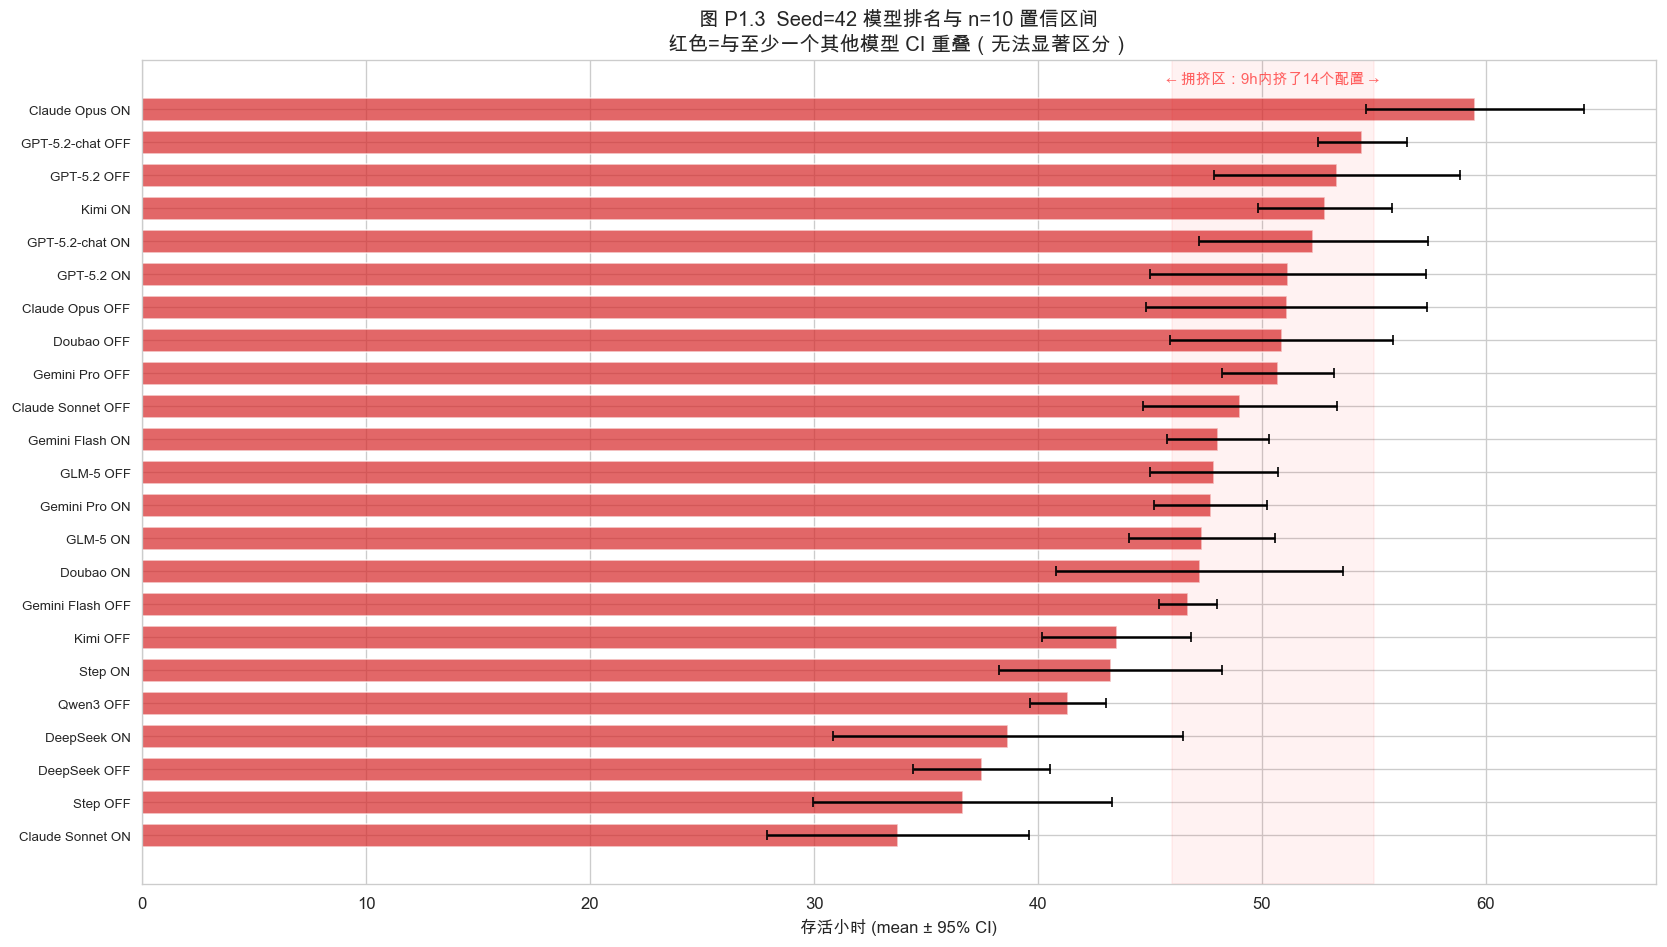


n=10 下 CI 重叠情况：159/253 对 (63%)
无法显著区分的模型：23/23 个

结论：n=10 足以区分 delta>5h 的模型（头部 vs 尾部），
但中间 46-55h 的拥挤区内 15 个配置无法排序。
对于接近模型，建议 n=20+。


In [33]:
# ── 图 P1.3：Seed=42 模型排名拥挤度分析 ──

import os

SEED42_DIR = BASE / 'eval_results' / 'seed_42'

TAG_MAP_42 = {
    'claude_opus_off':    'Claude Opus OFF',
    'claude_opus_on':     'Claude Opus ON',
    'claude_sonnet_off':  'Claude Sonnet OFF',
    'claude_sonnet_on':   'Claude Sonnet ON',
    'gpt52_off':          'GPT-5.2 OFF',
    'gpt52_on':           'GPT-5.2 ON',
    'gpt52_chat_off':     'GPT-5.2-chat OFF',
    'gpt52_chat_on':      'GPT-5.2-chat ON',
    'gemini_3_pro_off':   'Gemini Pro OFF',
    'gemini_3_pro_high':  'Gemini Pro ON',
    'gemini_3_flash_off': 'Gemini Flash OFF',
    'gemini_3_flash_high':'Gemini Flash ON',
    'deepseek_v32_off':   'DeepSeek OFF',
    'deepseek_v32_on':    'DeepSeek ON',
    'kimi_25_off':        'Kimi OFF',
    'kimi_25_on':         'Kimi ON',
    'doubao-v18_off':     'Doubao OFF',
    'doubao-v18_on':      'Doubao ON',
    'glm_5_off':          'GLM-5 OFF',
    'glm_5_on':           'GLM-5 ON',
    'step_35_flash_off':  'Step OFF',
    'step_35_flash_on':   'Step ON',
    'qwen3_max_off':      'Qwen3 OFF',
}

def load_seed42_hours(model_tag):
    files = sorted(glob.glob(str(SEED42_DIR / model_tag / 'run_*.jsonl')))
    hours = []
    for f in files:
        lines = [json.loads(l) for l in open(f) if l.strip()]
        final = [l for l in lines if l.get('type') == 'final_score']
        if final:
            hours.append(final[0]['scores']['hours_survived'])
            continue
        tick_lines = [l for l in lines if 'tick' in l]
        if tick_lines:
            h = tick_lines[-1].get('hours_elapsed', 0)
            if h > 0:
                hours.append(h)
    return hours

# 加载全部 seed=42 数据
seed42_results = []
for tag, label in TAG_MAP_42.items():
    h = load_seed42_hours(tag)
    if h:
        seed42_results.append({'tag': tag, 'label': label,
                               'mean': np.mean(h), 'std': np.std(h),
                               'n': len(h), 'hours': h})

seed42_results.sort(key=lambda x: -x['mean'])

# ── 可视化：排名 + 置信区间重叠 ──
fig, ax = plt.subplots(figsize=(14, 8))

y_pos = range(len(seed42_results))
means = [r['mean'] for r in seed42_results]
stds = [r['std'] for r in seed42_results]
labels = [r['label'] for r in seed42_results]

# 根据 Phase 1 结论：n=10 时 MAE≈2h，95%CI≈±3-4h
ci_half = [1.96 * r['std'] / np.sqrt(r['n']) for r in seed42_results]

# 着色：CI 与相邻模型重叠的标红
colors = []
for i in range(len(seed42_results)):
    overlaps = False
    lo_i = means[i] - ci_half[i]
    hi_i = means[i] + ci_half[i]
    for j in range(len(seed42_results)):
        if i == j: continue
        lo_j = means[j] - ci_half[j]
        hi_j = means[j] + ci_half[j]
        if lo_i < hi_j and lo_j < hi_i:
            overlaps = True
            break
    colors.append('#d62728' if overlaps else '#2ca02c')

ax.barh(y_pos, means, xerr=ci_half, color=colors, alpha=0.7, capsize=3, height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('存活小时 (mean ± 95% CI)')
ax.set_title('图 P1.3  Seed=42 模型排名与 n=10 置信区间\n红色=与至少一个其他模型 CI 重叠（无法显著区分）')

# 标注拥挤区
ax.axvspan(46, 55, alpha=0.05, color='red')
ax.text(50.5, -0.8, '← 拥挤区：9h内挤了14个配置 →', ha='center', fontsize=9, color='red', alpha=0.6)

plt.tight_layout()
fig.savefig(FIGURES / 'fig_P1_3_seed42_ranking.png', bbox_inches='tight')
plt.show()

# 统计 CI 重叠对数
overlap_pairs = 0
for i in range(len(seed42_results)):
    for j in range(i+1, len(seed42_results)):
        lo_i = means[i] - ci_half[i]
        hi_i = means[i] + ci_half[i]
        lo_j = means[j] - ci_half[j]
        hi_j = means[j] + ci_half[j]
        if lo_i < hi_j and lo_j < hi_i:
            overlap_pairs += 1

total_pairs = len(seed42_results) * (len(seed42_results) - 1) // 2
print(f'\nn=10 下 CI 重叠情况：{overlap_pairs}/{total_pairs} 对 ({overlap_pairs/total_pairs*100:.0f}%)')
print(f'无法显著区分的模型：{sum(1 for c in colors if c == "#d62728")}/{len(colors)} 个')
print(f'\n结论：n=10 足以区分 delta>5h 的模型（头部 vs 尾部），')
print(f'但中间 46-55h 的拥挤区内 {sum(1 for r in seed42_results if 46 <= r["mean"] <= 55)} 个配置无法排序。')
print(f'对于接近模型，建议 n=20+。')

In [34]:
# ── Phase 1 结论汇总 ──

print('=' * 60)
print('Phase 1 大规模采样充分性验证 —— 结论')
print('=' * 60)
print()
print('数据规模：2 模型 × 3 seeds × 100 轮 = 600 局')
print()
print('1. 分布形态')
for label in PHASE1_MODELS.values():
    for seed in PHASE1_SEEDS:
        h = phase1_data[(label, seed)]
        if len(h) > 8:
            _, sw_p = stats.shapiro(h[:500])
            normal = '正态' if sw_p > 0.05 else '非正态'
            skew = stats.skew(h)
            print(f'   {label} seed={seed}: Shapiro p={sw_p:.3f} ({normal}), 偏度={skew:.2f}')

print()
print('2. 采样充分性')
random.seed(42)
for n in [10, 20]:
    all_maes = []
    for label in PHASE1_MODELS.values():
        for seed in PHASE1_SEEDS:
            h = phase1_data[(label, seed)]
            if not h: continue
            true_mean = np.mean(h)
            errors = [abs(np.mean(random.choices(h, k=n)) - true_mean) for _ in range(1000)]
            all_maes.append(np.mean(errors))
    print(f'   n={n}: MAE={np.mean(all_maes):.2f}h')

print()
print('3. 实操建议')
print('   - n=10：适合模型间 delta>5h 的粗筛（排名正确率>85%）')
print('   - n=20：对接近模型的排名正确率显著提升，MAE 降至 ~1.4h')
print('   - 多 seed 汇总可进一步降低环境偏差')
print()
print('4. Seed=42 回验')
print(f'   24 配置中，46-55h 区间内有 {sum(1 for r in seed42_results if 46 <= r["mean"] <= 55)} 个配置')
print('   这些配置在 n=10 下 CI 大量重叠，无法可靠排序')
print('   头部（>55h）和尾部（<40h）模型可被 n=10 可靠区分')

Phase 1 大规模采样充分性验证 —— 结论

数据规模：2 模型 × 3 seeds × 100 轮 = 600 局

1. 分布形态
   Gemini Flash seed=7: Shapiro p=0.000 (非正态), 偏度=-1.77
   Gemini Flash seed=233: Shapiro p=0.000 (非正态), 偏度=-1.06
   Gemini Flash seed=999: Shapiro p=0.000 (非正态), 偏度=-0.92
   Doubao v1.8 seed=7: Shapiro p=0.000 (非正态), 偏度=-1.75
   Doubao v1.8 seed=233: Shapiro p=0.342 (正态), 偏度=0.03
   Doubao v1.8 seed=999: Shapiro p=0.085 (正态), 偏度=-0.08

2. 采样充分性
   n=10: MAE=1.93h
   n=20: MAE=1.36h

3. 实操建议
   - n=10：适合模型间 delta>5h 的粗筛（排名正确率>85%）
   - n=20：对接近模型的排名正确率显著提升，MAE 降至 ~1.4h
   - 多 seed 汇总可进一步降低环境偏差

4. Seed=42 回验
   24 配置中，46-55h 区间内有 15 个配置
   这些配置在 n=10 下 CI 大量重叠，无法可靠排序
   头部（>55h）和尾部（<40h）模型可被 n=10 可靠区分
